# Phần 2: Tiền xử lý dữ liệu dạng bảng – IEEE-CIS Fraud Detection

**Dataset:** IEEE-CIS Fraud Detection  
- `train_transaction.csv`, `train_identity.csv`  
- `test_transaction.csv`, `test_identity.csv`  
- Bài toán phân loại nhị phân: dự đoán `isFraud`  
- Dữ liệu có cả thuộc tính số và phân loại, nhiều giá trị thiếu, mất cân bằng lớp nghiêm trọng.

In [1]:
# ============================================================
# 0. Cài đặt thư viện cần thiết
# ============================================================
!pip install missingno pyampute category_encoders umap-learn imbalanced-learn scikit-learn scipy statsmodels

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import os

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 80
pd.options.display.max_rows = 60
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
SEED = 42
np.random.seed(SEED)

## 0. Load & merge dữ liệu

In [3]:
# ── Đường dẫn dữ liệu ──────────────────────────────────────────────────────
# Tự động nhận diện môi trường Kaggle vs máy local
import os

IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    # Kaggle: input read-only, ghi ra /kaggle/working/
    DATA_DIR   = '/kaggle/input/ieee-fraud-detection'  # <- thay tên dataset nếu cần
    OUTPUT_DIR = '/kaggle/working'
else:
    # Local: cùng thư mục với file script
    DATA_DIR   = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else '.'
    OUTPUT_DIR = DATA_DIR  # local: đọc & ghi cùng thư mục

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"{'[Kaggle]' if IS_KAGGLE else '[Local]'} DATA_DIR   = {DATA_DIR}")
print(f"{'[Kaggle]' if IS_KAGGLE else '[Local]'} OUTPUT_DIR = {OUTPUT_DIR}")

print("Đang tải dữ liệu...")
train_transaction = pd.read_csv(os.path.join(DATA_DIR, 'train_transaction.csv'))
train_identity    = pd.read_csv(os.path.join(DATA_DIR, 'train_identity.csv'))
test_transaction  = pd.read_csv(os.path.join(DATA_DIR, 'test_transaction.csv'))
test_identity     = pd.read_csv(os.path.join(DATA_DIR, 'test_identity.csv'))

# Merge transaction + identity theo TransactionID (left join)
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
test  = pd.merge(test_transaction,  test_identity,  on='TransactionID', how='left')

del train_transaction, train_identity, test_transaction, test_identity
gc.collect()

print(f"Train: {train.shape[0]:,} dòng × {train.shape[1]} cột")
print(f"Test : {test.shape[0]:,} dòng × {test.shape[1]} cột")

[Local] DATA_DIR   = .
[Local] OUTPUT_DIR = .
Đang tải dữ liệu...
Train: 590,540 dòng × 434 cột
Test : 506,691 dòng × 433 cột


In [4]:
# ── Giảm sử dụng bộ nhớ (downcast kiểu dữ liệu) ──────────────────────────────
def reduce_mem_usage(df, verbose=True):
    """Giảm bộ nhớ bằng cách chuyển kiểu dtype nhỏ hơn."""
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                for dtype in [np.int8, np.int16, np.int32, np.int64]:
                    if c_min > np.iinfo(dtype).min and c_max < np.iinfo(dtype).max:
                        df[col] = df[col].astype(dtype)
                        break
            else:
                if (c_min > np.finfo(np.float32).min and
                        c_max < np.finfo(np.float32).max):
                    df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"  Bộ nhớ giảm từ {start_mem:.1f} MB -> {end_mem:.1f} MB "
              f"({100*(start_mem-end_mem)/start_mem:.1f}%)")
    return df

train = reduce_mem_usage(train)
test  = reduce_mem_usage(test)
gc.collect()

  Bộ nhớ giảm từ 2567.1 MB -> 1656.4 MB (35.5%)
  Bộ nhớ giảm từ 2214.0 MB -> 1436.0 MB (35.1%)


0

#### Cell 1 – Shape, dtypes, memory usage

In [5]:
print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}\n")

# Phân loại dtype
dtype_summary = train.dtypes.value_counts()
print("Kiểu dữ liệu:")
print(dtype_summary.to_string())

mem_mb = train.memory_usage(deep=True).sum() / 1024**2
print(f"\nBộ nhớ train: {mem_mb:.1f} MB")

Train shape : (590540, 434)
Test  shape : (506691, 433)

Kiểu dữ liệu:
float32    399
object      31
int32        2
int8         1
int16        1

Bộ nhớ train: 1656.4 MB


---
## 2.2.2. Phân tích thống kê khám phá (EDA)

### a) Kiểm tra phân phối – D'Agostino-Pearson (vì n > 5000)

#### Kiểm tra phân phối là gì và tại sao cần?

**Kiểm tra phân phối** (normality test) xác định liệu một thuộc tính có tuân theo **phân phối chuẩn** $\mathcal{N}(\mu, \sigma^2)$ hay không.
Kết quả ảnh hưởng trực tiếp đến các bước tiếp theo:

| Nếu phân phối... | Dùng correlation | Dùng scaler |
|---|---|---|
| Gần chuẩn (symmetric) | Pearson | StandardScaler |
| Lệch / có outlier | Spearman | RobustScaler hoặc QuantileTransformer |

#### Shapiro-Wilk là gì?

**Shapiro-Wilk** (1965) là kiểm định phân phối chuẩn phổ biến nhất, hoạt động bằng cách
so sánh các **order statistics** (giá trị đã sắp xếp) của mẫu với các order statistics kỳ vọng
của phân phối chuẩn lý thuyết:

$$W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

$W$ càng gần 1 thì dữ liệu càng gần chuẩn. Tuy nhiên, **Shapiro-Wilk mất hiệu lực khi $n > 5\,000$**:
với mẫu lớn, power của test tăng rất cao khiến test phát hiện ra những lệch chuẩn cực nhỏ
không có ý nghĩa thực tế và gần như luôn bác bỏ $H_0$.

#### D'Agostino-Pearson là gì?

**D'Agostino-Pearson** (`scipy.stats.normaltest`) là kiểm định phù hợp hơn cho dataset lớn.
Thay vì so sánh toàn bộ phân phối, nó chỉ kiểm tra hai đặc trưng hình dạng đặc trưng của phân phối chuẩn:

- **Skewness** $\hat{\gamma}_1$: đo tính đối xứng của phân phối. Phân phối chuẩn hoàn toàn đối xứng nên $\gamma_1 = 0$. Giá trị dương → đuôi phải dài hơn; âm → đuôi trái dài hơn.
- **Excess kurtosis** $\hat{\gamma}_2$: đo độ "nhọn" và độ nặng của đuôi. Phân phối chuẩn có $\gamma_2 = 0$. Giá trị dương → đuôi nặng hơn chuẩn (leptokurtic); âm → đuôi nhẹ hơn (platykurtic).

Hai đại lượng này được chuẩn hóa thành $Z_1, Z_2$ rồi kết hợp thành thống kê tổng hợp phân phối $\chi^2(2)$:

$$K^2 = Z_1(\hat{\gamma}_1)^2 + Z_2(\hat{\gamma}_2)^2 \;\sim\; \chi^2(2) \quad \text{dưới } H_0$$

- **$H_0$**: dữ liệu tuân theo phân phối chuẩn
- $p > 0.05$: không bác bỏ $H_0$ – thuộc tính gần chuẩn
- $p \leq 0.05$: bác bỏ $H_0$ – thuộc tính lệch hoặc có đuôi nặng

In [6]:
from scipy import stats

# Chỉ lấy các cột số (không phải target, không phải ID)
num_cols = [c for c in train.select_dtypes(include=[np.number]).columns
            if c not in ('isFraud', 'TransactionID', 'TransactionDT')]

print(f"Số cột số: {len(num_cols)}")

# Chạy D'Agostino-Pearson test trên mẫu tối đa 20,000 dòng để tiết kiệm thời gian
SAMPLE_N = min(20_000, len(train))
sample_df = train[num_cols].dropna(axis=1, how='all').sample(SAMPLE_N, random_state=SEED)

normality_results = []
for col in sample_df.columns:
    col_data = sample_df[col].dropna()
    if len(col_data) < 8:
        continue
    stat, p = stats.normaltest(col_data)
    normality_results.append({
        'feature': col,
        'statistic': round(stat, 4),
        'p_value': round(p, 6),
        'is_normal': p > 0.05
    })

normality_df = pd.DataFrame(normality_results)
n_normal = normality_df['is_normal'].sum()
print(f"\nSố thuộc tính phân phối chuẩn (p>0.05): {n_normal}/{len(normality_df)}")
print(f"Số thuộc tính KHÔNG phân phối chuẩn  : {len(normality_df)-n_normal}/{len(normality_df)}")
print("\n10 thuộc tính có p-value cao nhất (gần chuẩn nhất):")
print(normality_df.sort_values('p_value', ascending=False).head(10).to_string(index=False))

Số cột số: 400

Số thuộc tính phân phối chuẩn (p>0.05): 1/400
Số thuộc tính KHÔNG phân phối chuẩn  : 399/400

10 thuộc tính có p-value cao nhất (gần chuẩn nhất):
       feature  statistic  p_value  is_normal
         id_25     0.9335 0.627049       True
         id_07     6.8763 0.032124      False
         id_08    17.2449 0.000180      False
         id_26    25.0931 0.000004      False
TransactionAmt 25678.2828 0.000000      False
          V225 10950.8249 0.000000      False
          V234  5426.9269 0.000000      False
          V233 10822.9688 0.000000      False
          V232 10524.6841 0.000000      False
          V231 10994.2621 0.000000      False


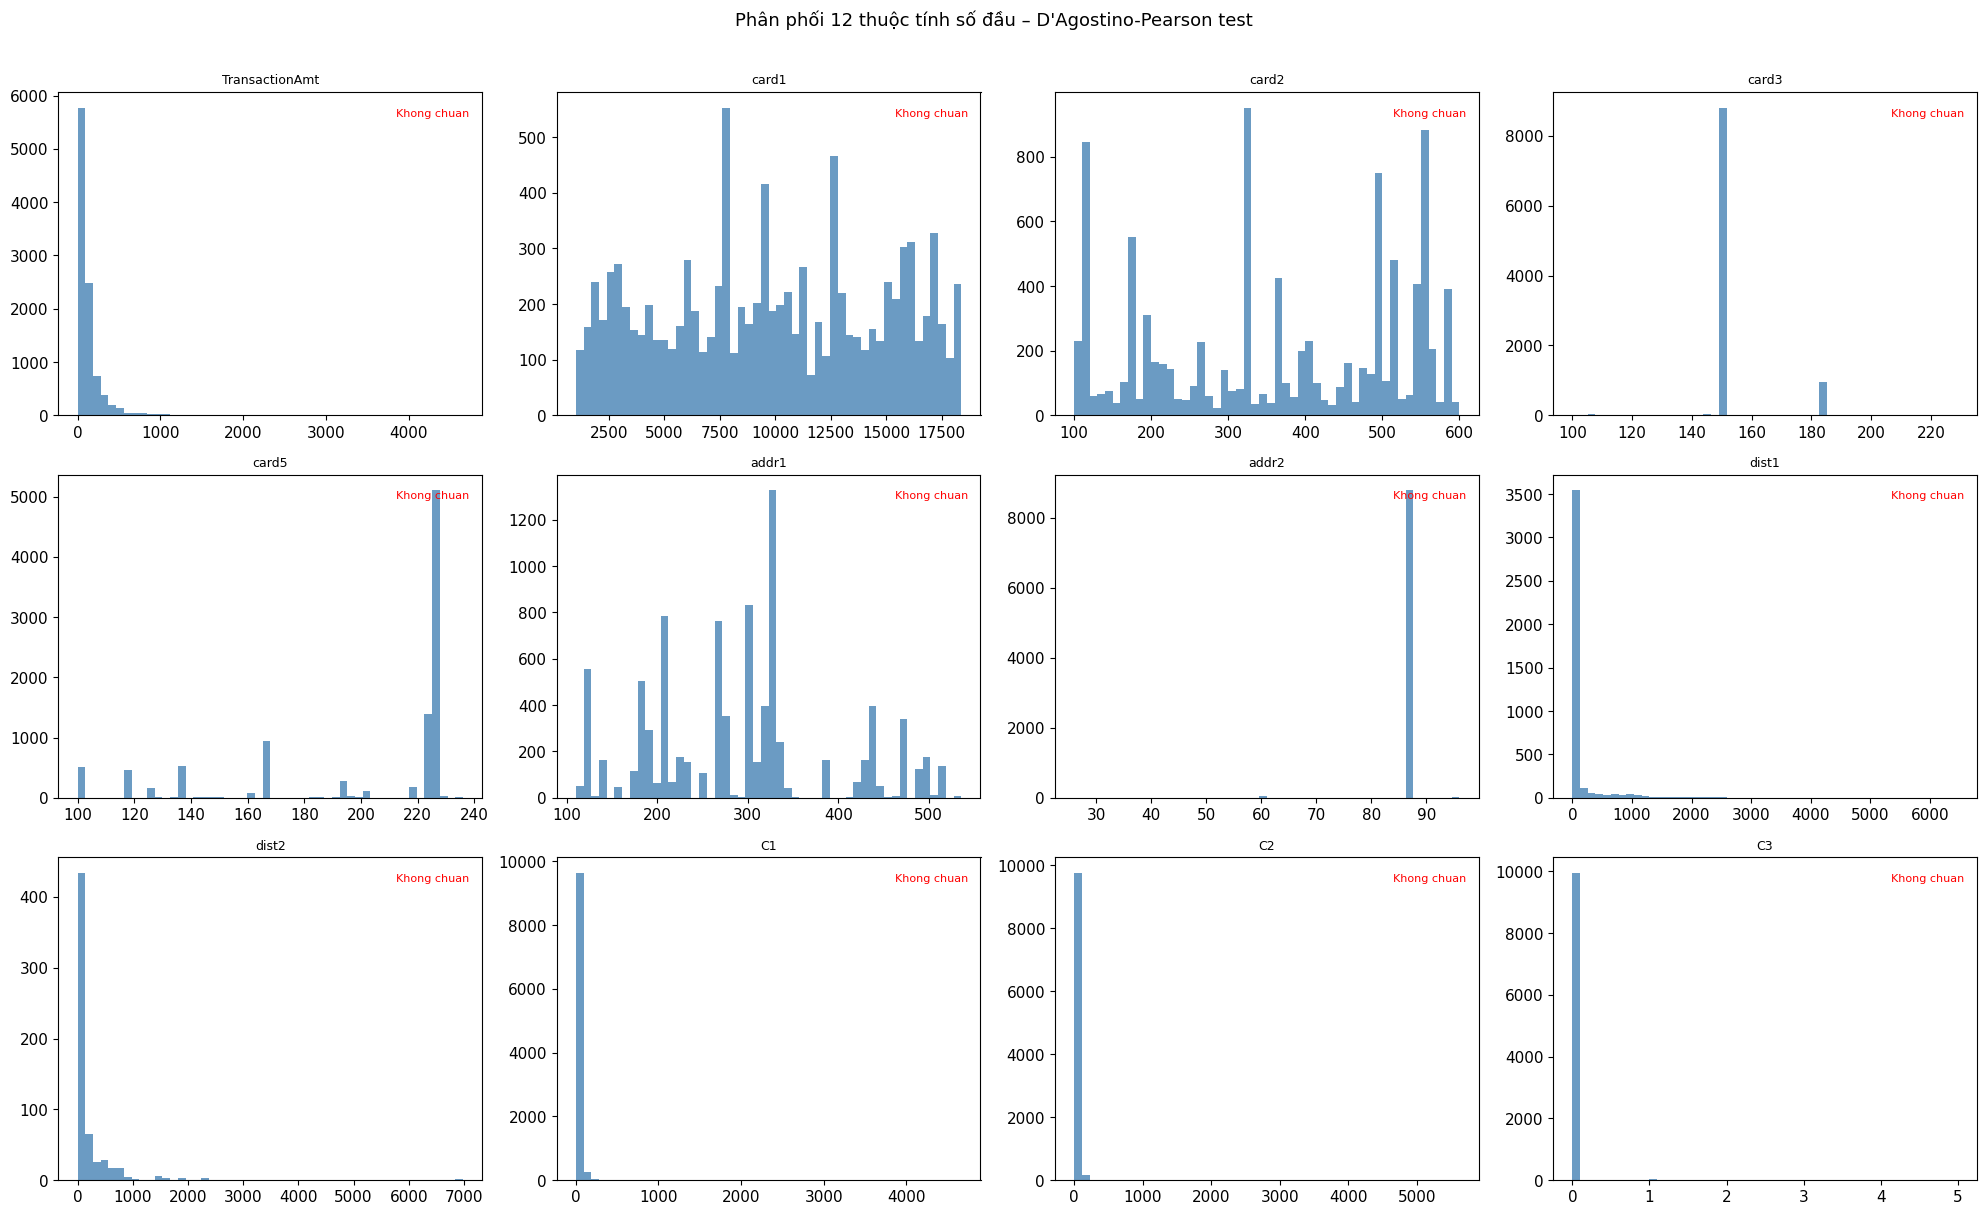

In [7]:

# Biểu đồ phân phối của 12 thuộc tính số đầu tiên
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
# KHÔNG dùng .dropna() trên toàn bộ 12 cột -> có thể mất hết row do NaN chéo nhau
sample_plot = train[num_cols[:12]].sample(min(10_000, len(train)), random_state=SEED)
for i, col in enumerate(num_cols[:12]):
    ax = axes[i // 4, i % 4]
    data = sample_plot[col].dropna()   # dropna chỉ cho cột này
    if len(data) == 0:
        ax.set_title(f'{col} (no data)', fontsize=9)
        continue
    ax.hist(data, bins=50, edgecolor='none', color='steelblue', alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    is_norm = normality_df.loc[normality_df.feature == col, 'is_normal']
    label = "Chuan" if (len(is_norm) > 0 and is_norm.values[0]) else "Khong chuan"
    ax.text(0.97, 0.95, label, ha='right', va='top', transform=ax.transAxes,
            fontsize=8, color='green' if 'Chuan' == label else 'red')
plt.suptitle("Phân phối 12 thuộc tính số đầu – D'Agostino-Pearson test", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_01_distributions.png'), dpi=100, bbox_inches='tight')
plt.show()

### b) Phân tích tương quan đa biến – Pearson & Spearman

| Phương pháp | Công thức | Giả định | Khi nào dùng |
|---|---|---|---|
| **Pearson** | $r = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$ | Tuyến tính, phân phối chuẩn | Dữ liệu chuẩn, quan hệ tuyến tính |
| **Spearman** | $r_s = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$ | Đơn điệu, phi tham số | Dữ liệu lệch, có outlier |

**Phát hiện đa cộng tuyến** ($|r| > 0.9$): hai đặc trưng tương quan cao chứa thông tin gần như trùng lặp.
Trong mô hình tuyến tính, đa cộng tuyến làm hệ số hồi quy không ổn định (phương sai lớn).
Giải pháp: loại một trong hai cột hoặc dùng PCA để kết hợp.

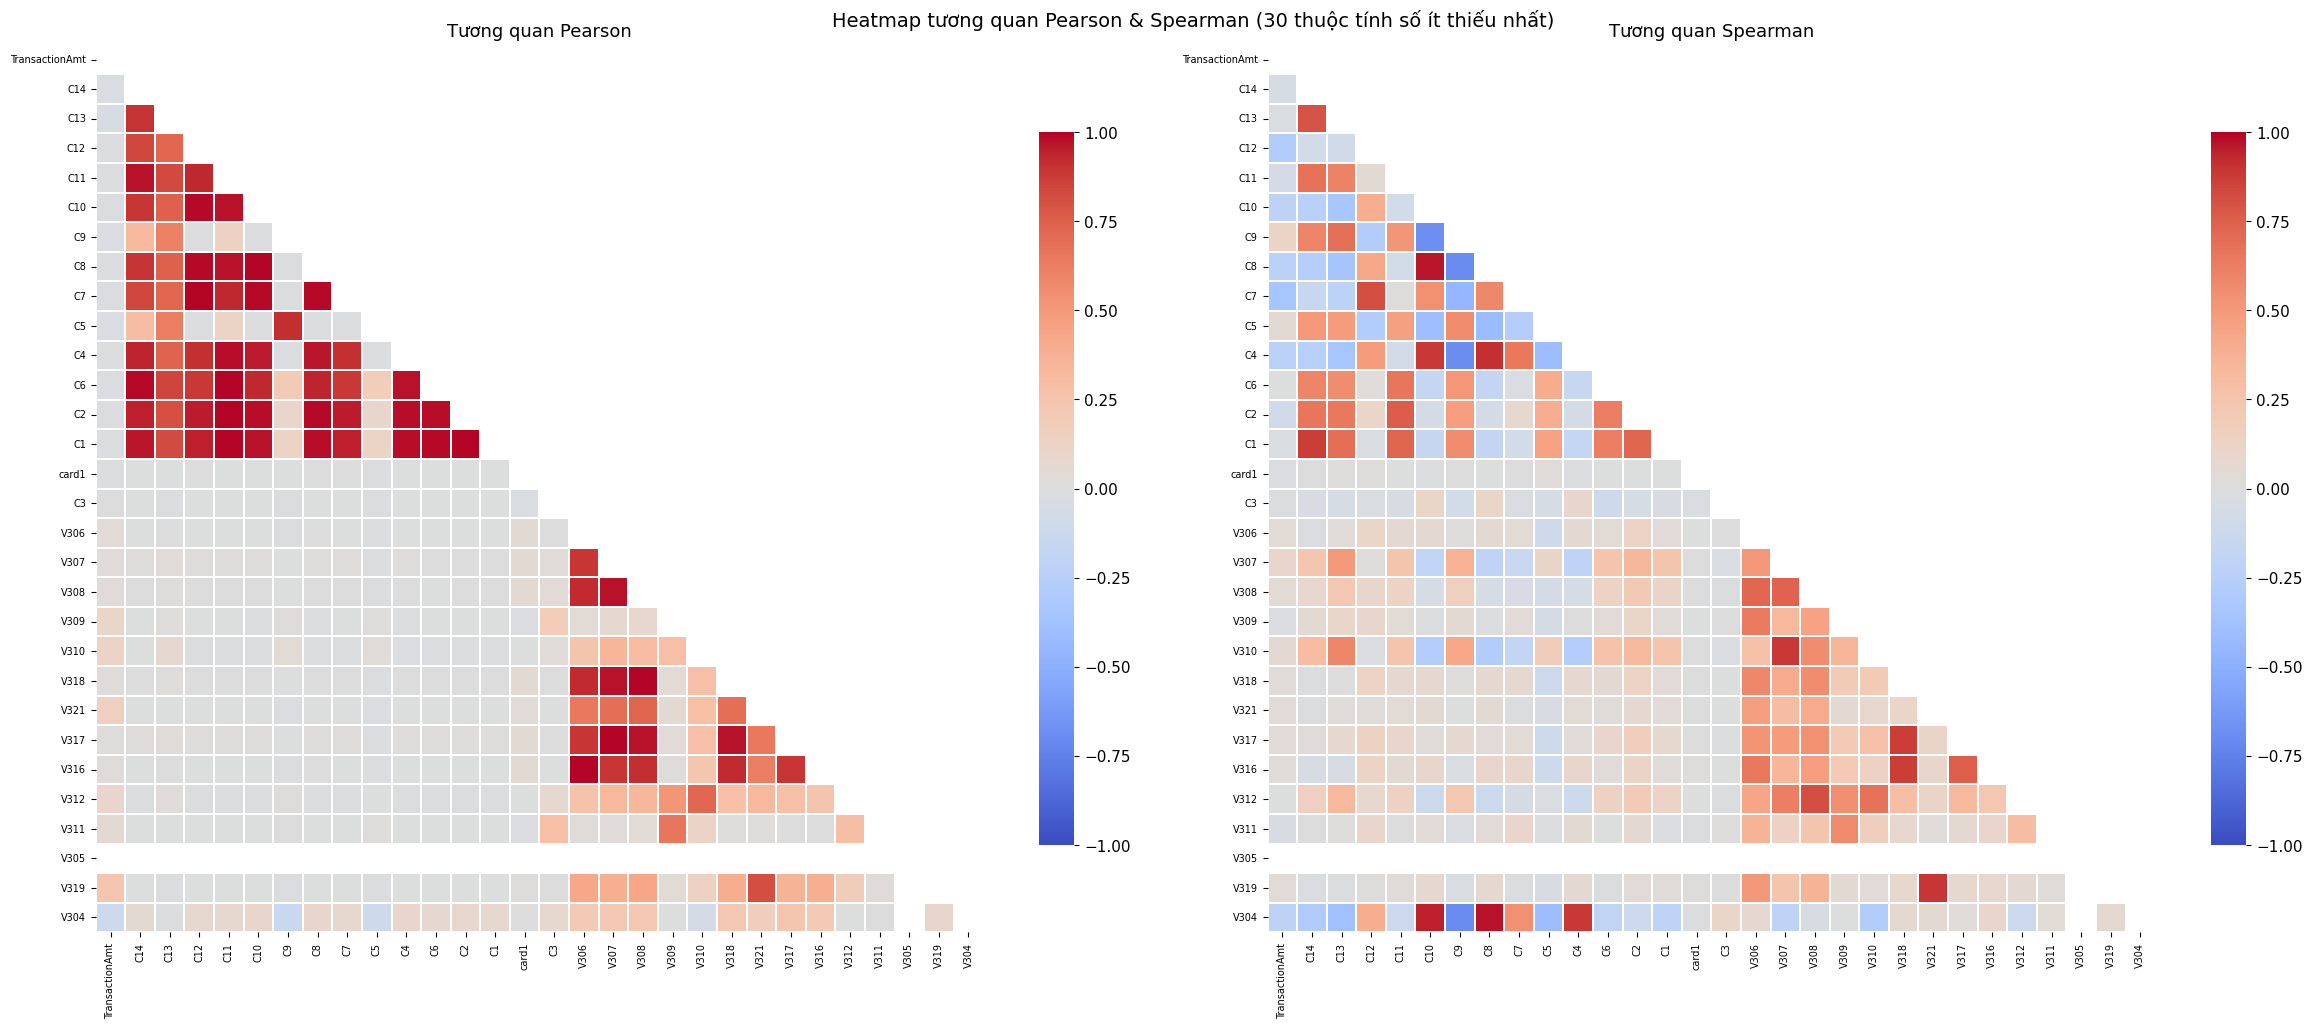

In [8]:
# Chọn tối đa 30 thuộc tính số có ít giá trị thiếu nhất để vẽ heatmap
miss_rate = train[num_cols].isnull().mean()
top_num_cols = miss_rate.sort_values().head(30).index.tolist()

sample_corr = train[top_num_cols].sample(min(10_000, len(train)), random_state=SEED)

pearson_corr  = sample_corr.corr(method='pearson')
spearman_corr = sample_corr.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

sns.heatmap(pearson_corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=axes[0], square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.8}, xticklabels=True, yticklabels=True)
axes[0].set_title('Tương quan Pearson', fontsize=13)
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

sns.heatmap(spearman_corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=axes[1], square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.8}, xticklabels=True, yticklabels=True)
axes[1].set_title('Tương quan Spearman', fontsize=13)
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.suptitle('Heatmap tương quan Pearson & Spearman (30 thuộc tính số ít thiếu nhất)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_02_correlation_heatmap.png'), dpi=100, bbox_inches='tight')
plt.show()

In [9]:
# Phát hiện đa cộng tuyến mạnh |r| > 0.9
high_corr_pairs = []
for i in range(len(pearson_corr.columns)):
    for j in range(i + 1, len(pearson_corr.columns)):
        r = pearson_corr.iloc[i, j]
        if abs(r) > 0.9:
            high_corr_pairs.append({
                'feature_1': pearson_corr.columns[i],
                'feature_2': pearson_corr.columns[j],
                'pearson_r': round(r, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
print(f"Số cặp thuộc tính có |Pearson r| > 0.9: {len(high_corr_df)}")
if len(high_corr_df) > 0:
    print(high_corr_df.to_string(index=False))
    print("\n-> Đề xuất: loại bỏ một trong mỗi cặp đa cộng tuyến mạnh khi huấn luyện mô hình.")
else:
    print("-> Không phát hiện đa cộng tuyến mạnh trong 30 thuộc tính khảo sát.")

Số cặp thuộc tính có |Pearson r| > 0.9: 51
feature_1 feature_2  pearson_r
      C14       C11     0.9725
      C14        C4     0.9418
      C14        C6     0.9899
      C14        C2     0.9526
      C14        C1     0.9633
      C12       C11     0.9346
      C12       C10     0.9869
      C12        C8     0.9861
      C12        C7     0.9997
      C12        C4     0.9110
      C12        C2     0.9556
      C12        C1     0.9474
      C11       C10     0.9694
      C11        C8     0.9738
      C11        C7     0.9343
      C11        C4     0.9835
      C11        C6     0.9923
      C11        C2     0.9958
      C11        C1     0.9978
      C10        C8     0.9983
      C10        C7     0.9877
      C10        C4     0.9605
      C10        C6     0.9352
      C10        C2     0.9810
      C10        C1     0.9743
       C9        C5     0.9157
       C8        C7     0.9861
       C8        C4     0.9656
       C8        C6     0.9404
       C8        C2     0.9

### c) Phân tích giá trị thiếu – missingno + Little's MCAR test

Có ba cơ chế thiếu dữ liệu cần phân biệt để chọn chiến lược xử lý phù hợp:

| Cơ chế | Ý nghĩa | Chiến lược khuyến nghị |
|---|---|---|
| **MCAR** – Missing Completely At Random | Xác suất thiếu không phụ thuộc vào bất kỳ biến nào | Mean/Median imputation là an toàn |
| **MAR** – Missing At Random | Xác suất thiếu phụ thuộc vào biến khác đã quan sát được | kNN, MICE (khai thác cấu trúc) |
| **MNAR** – Missing Not At Random | Xác suất thiếu phụ thuộc vào chính giá trị bị thiếu | Cần domain knowledge; khó xử lý |

**Little's MCAR test** kiểm định giả thuyết MCAR bằng thống kê $\chi^2$:
so sánh mean của từng *missing pattern* (nhóm hàng có cùng vị trí thiếu) với grand mean.

$$\chi^2 = \sum_{g} n_g \sum_{j \in O_g} \frac{(\bar{x}_{gj} - \bar{x}_j)^2}{\hat{\sigma}_j^2}$$

Nếu $p < 0.05$ → bác bỏ MCAR → dữ liệu có khả năng là MAR hoặc MNAR → nên dùng kNN/MICE.

#### Cell 3 – Tỉ lệ thiếu theo nhóm cột

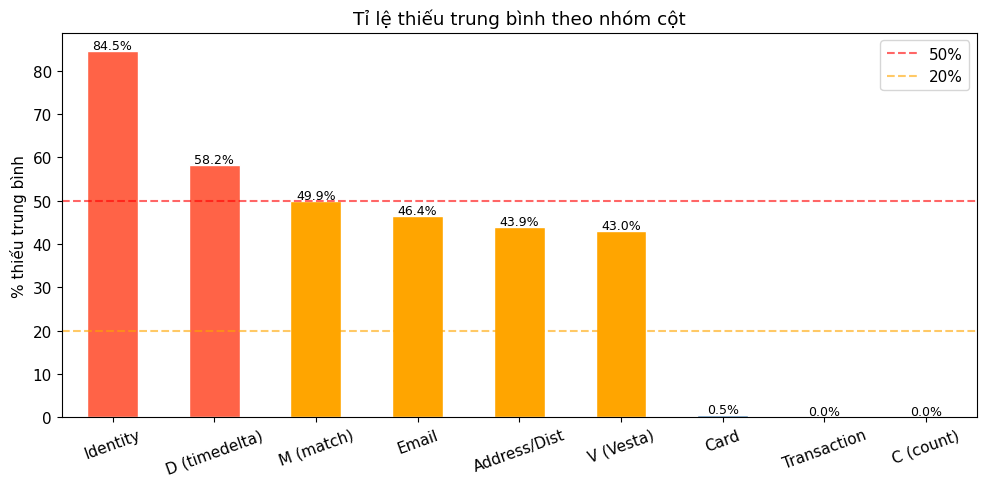

In [10]:
# Định nghĩa 9 nhóm cột
groups = {
    'Transaction'  : ['TransactionDT', 'TransactionAmt', 'ProductCD'],
    'Card'         : [f'card{i}' for i in range(1, 7)],
    'Address/Dist' : ['addr1', 'addr2', 'dist1', 'dist2'],
    'Email'        : ['P_emaildomain', 'R_emaildomain'],
    'C (count)'    : [f'C{i}' for i in range(1, 15)],
    'D (timedelta)': [f'D{i}' for i in range(1, 16)],
    'M (match)'    : [f'M{i}' for i in range(1, 10)],
    'V (Vesta)'    : [c for c in train.columns if c.startswith('V')],
    'Identity'     : [c for c in train.columns if c.startswith('id_') or c in ('DeviceType', 'DeviceInfo')],
}

# Tỉ lệ thiếu trung bình theo nhóm
group_missing = {}
for grp, cols in groups.items():
    exist = [c for c in cols if c in train.columns]
    if exist:
        group_missing[grp] = train[exist].isnull().mean().mean() * 100

miss_series = pd.Series(group_missing).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tomato' if v > 50 else 'orange' if v > 20 else 'steelblue' for v in miss_series.values]
miss_series.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(50, color='red',    linestyle='--', alpha=0.6, label='50%')
ax.axhline(20, color='orange', linestyle='--', alpha=0.6, label='20%')
ax.set_ylabel('% thiếu trung bình')
ax.set_title('Tỉ lệ thiếu trung bình theo nhóm cột')
ax.legend()
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(miss_series.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_02_missing_by_group.png'), dpi=100, bbox_inches='tight')
plt.show()

#### Cell 4 – Heatmap missing pattern của V1–V339 (xác nhận 11 nhóm)

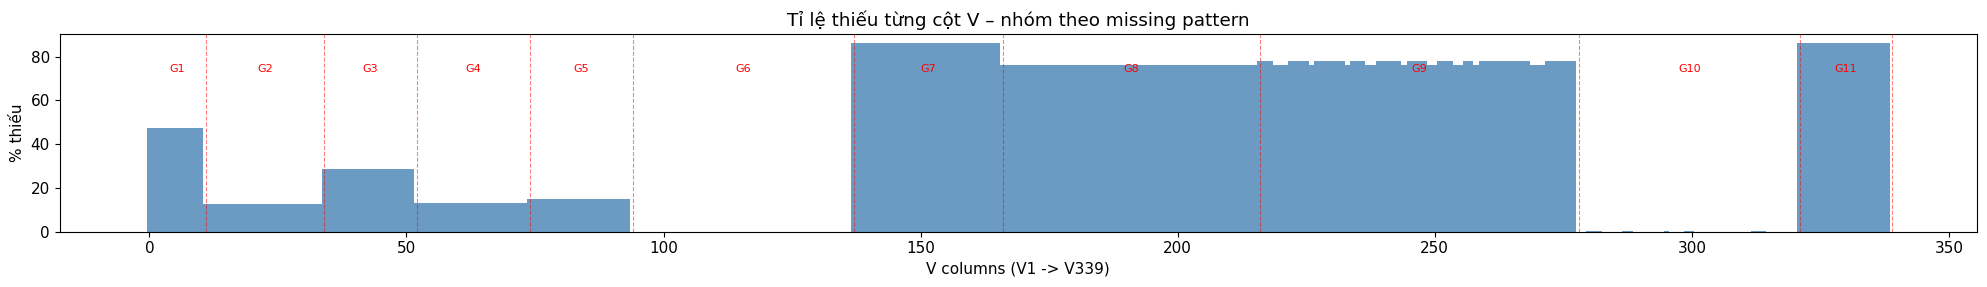

In [11]:
v_cols = [c for c in train.columns if c.startswith('V')]
# Tỉ lệ thiếu từng cột V
v_missing = train[v_cols].isnull().mean() * 100

fig, ax = plt.subplots(figsize=(20, 3))
ax.bar(range(len(v_cols)), v_missing.values, color='steelblue', alpha=0.8, width=1.0)
ax.set_xlabel('V columns (V1 -> V339)')
ax.set_ylabel('% thiếu')
ax.set_title('Tỉ lệ thiếu từng cột V – nhóm theo missing pattern')

# Đánh dấu ranh giới 11 nhóm theo Kaggle
group_boundaries = [11, 34, 52, 74, 94, 137, 166, 216, 278, 321, 339]
group_labels = [f'G{i+1}' for i in range(11)]
prev = 0
for b, lbl in zip(group_boundaries, group_labels):
    ax.axvline(b, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.text((prev + b) / 2, v_missing.max() * 0.85, lbl,
            ha='center', fontsize=8, color='red')
    prev = b

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_03_v_missing_pattern.png'), dpi=100, bbox_inches='tight')
plt.show()

In [12]:
import missingno as msno

# Ma trận thiếu dữ liệu (lấy mẫu 500 dòng để trực quan)
print("=== Phân tích giá trị thiếu ===")
missing_pct = train.isnull().mean().sort_values(ascending=False)
print(f"Số cột có giá trị thiếu: {(missing_pct > 0).sum()}")
print(f"Số cột có >50% thiếu   : {(missing_pct > 0.5).sum()}")
print(f"Số cột có >80% thiếu   : {(missing_pct > 0.8).sum()}")
print(f"Số cột có >90% thiếu   : {(missing_pct > 0.9).sum()}")

=== Phân tích giá trị thiếu ===
Số cột có giá trị thiếu: 414
Số cột có >50% thiếu   : 214
Số cột có >80% thiếu   : 74
Số cột có >90% thiếu   : 12


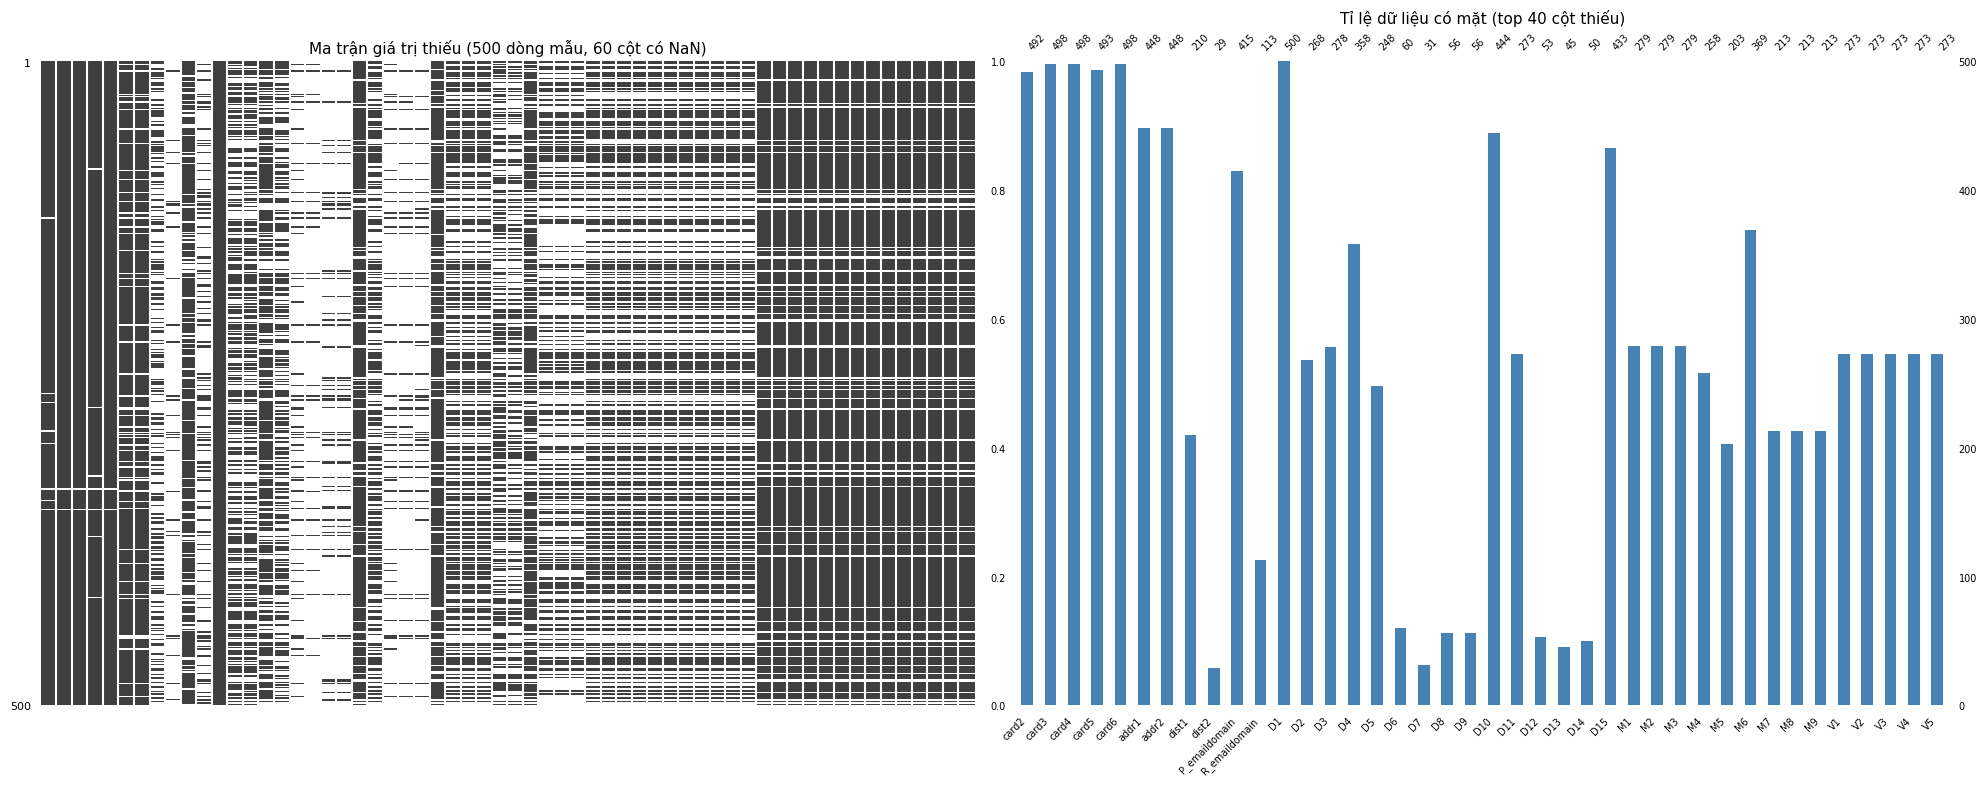

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Chỉ hiển thị cột có giá trị thiếu, giới hạn 60 cột đầu để plot đọc được
miss_cols = [c for c in train.columns if train[c].isnull().any()][:60]
sample_miss = train[miss_cols].sample(500, random_state=SEED)
msno.matrix(sample_miss, ax=axes[0], fontsize=7, sparkline=False)
axes[0].set_title(f'Ma trận giá trị thiếu (500 dòng mẫu, {len(miss_cols)} cột có NaN)', fontsize=11)

# Bar: top 40 cột thiếu nhiều nhất
sample_miss_bar = train[miss_cols[:40]].sample(500, random_state=SEED)
msno.bar(sample_miss_bar, ax=axes[1], fontsize=7, color='steelblue')
axes[1].set_title('Tỉ lệ dữ liệu có mặt (top 40 cột thiếu)', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_03_missing_matrix.png'), dpi=100, bbox_inches='tight')
plt.show()

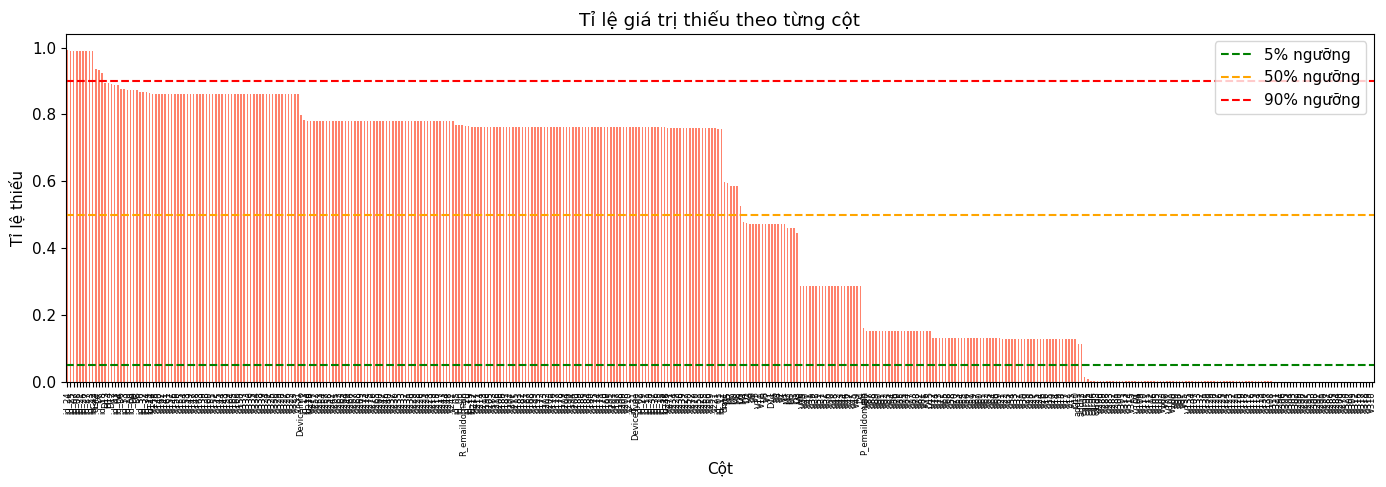

In [14]:
# Biểu đồ phân phối tỉ lệ thiếu
fig, ax = plt.subplots(figsize=(14, 5))
missing_pct[missing_pct > 0].plot(kind='bar', ax=ax, color='tomato', alpha=0.8)
ax.axhline(0.05, color='green', linestyle='--', label='5% ngưỡng')
ax.axhline(0.5,  color='orange', linestyle='--', label='50% ngưỡng')
ax.axhline(0.9,  color='red',    linestyle='--', label='90% ngưỡng')
ax.set_xlabel('Cột')
ax.set_ylabel('Tỉ lệ thiếu')
ax.set_title('Tỉ lệ giá trị thiếu theo từng cột')
ax.legend()
ax.tick_params(axis='x', rotation=90, labelsize=6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_04_missing_bar.png'), dpi=100, bbox_inches='tight')
plt.show()

In [15]:
# ── Little's MCAR test (gần đúng bằng chi-square trên tập con) ───────────────
# Thực hiện trên tối đa 30 cột số và 5000 dòng
def littles_mcar_approx(df, n_sample=5000, random_state=42):
    """
    Gần đúng Little's MCAR test bằng kiểm định chi-square.
    - Mỗi pattern thiếu là một nhóm; so sánh mean với grand mean.
    - Trả về p-value (p > 0.05 -> không bác bỏ MCAR).
    """
    df = df.sample(min(n_sample, len(df)), random_state=random_state)
    df = df.dropna(axis=1, how='all')
    # Tạo binary missing-indicator matrix
    r = df.isnull().astype(int)
    patterns = r.apply(lambda row: tuple(row), axis=1)
    groups = df.groupby(patterns)
    
    chi2 = 0.0
    df_deg = 0
    grand_means = df.mean()
    grand_vars  = df.var()
    
    for _, grp in groups:
        n_g = len(grp)
        if n_g < 2:
            continue
        obs_cols = grp.columns[grp.notna().all()].tolist()
        if not obs_cols:
            continue
        for col in obs_cols:
            gm = grand_means[col]
            gv = grand_vars[col]
            if gv == 0 or np.isnan(gv):
                continue
            chi2 += n_g * (grp[col].mean() - gm)**2 / gv
            df_deg += 1
    
    if df_deg == 0:
        return np.nan, np.nan
    p_val = 1 - stats.chi2.cdf(chi2, df=df_deg)
    return round(chi2, 4), round(p_val, 6)

test_cols_little = top_num_cols[:20]
chi2_stat, p_mcar = littles_mcar_approx(train[test_cols_little])
print(f"\n=== Little's MCAR test (gần đúng) ===")
print(f"  Chi2 statistic : {chi2_stat}")
print(f"  p-value        : {p_mcar}")
if not np.isnan(p_mcar):   # Dùng np.isnan() thay vì 'is not', tránh so sánh identity
    if p_mcar > 0.05:
        print("  -> Không bác bỏ H0 (MCAR): dữ liệu thiếu có thể là hoàn toàn ngẫu nhiên.")
    else:
        print("  -> Bác bỏ H0 (MCAR): dữ liệu thiếu KHÔNG hoàn toàn ngẫu nhiên -> MAR hoặc MNAR.")
        print("  -> Phân tích thêm: kiểm tra tương quan giữa chỉ báo thiếu và các cột khác.")


=== Little's MCAR test (gần đúng) ===
  Chi2 statistic : 0.0
  p-value        : 1.0
  -> Không bác bỏ H0 (MCAR): dữ liệu thiếu có thể là hoàn toàn ngẫu nhiên.


In [16]:
# Phân loại cơ chế thiếu
print("\n=== Phân loại cơ chế thiếu dữ liệu ===")
# Kiểm tra tương quan giữa biến chỉ báo thiếu và isFraud
miss_indicator_corr = {}
for col in num_cols[:50]:
    miss_rate_col = train[col].isnull().mean()
    if 0 < miss_rate_col < 1:
        indicator = train[col].isnull().astype(int)
        corr = indicator.corr(train['isFraud'])
        miss_indicator_corr[col] = round(corr, 4)

miss_indicator_df = pd.DataFrame.from_dict(
    miss_indicator_corr, orient='index', columns=['corr_with_target']
).sort_values('corr_with_target', key=abs, ascending=False)

print("Top 10 thuộc tính có chỉ báo thiếu tương quan cao nhất với isFraud:")
print(miss_indicator_df.head(10).to_string())
print("\n-> Kết luận: Nếu nhiều cột có tương quan cao (>0.1) giữa missing indicator và target")
print("  -> dữ liệu có khả năng là MAR (Missing At Random) hoặc MNAR (Not At Random).")
print("  -> Chiến lược: Nên dùng k-NN imputation hoặc MICE thay vì thống kê đơn giản.")


=== Phân loại cơ chế thiếu dữ liệu ===
Top 10 thuộc tính có chỉ báo thiếu tương quan cao nhất với isFraud:
       corr_with_target
D7              -0.1645
addr1            0.1595
addr2            0.1595
D12             -0.1573
D14             -0.1512
D6              -0.1442
D9              -0.1441
D8              -0.1441
D13             -0.1404
dist2           -0.0911

-> Kết luận: Nếu nhiều cột có tương quan cao (>0.1) giữa missing indicator và target
  -> dữ liệu có khả năng là MAR (Missing At Random) hoặc MNAR (Not At Random).
  -> Chiến lược: Nên dùng k-NN imputation hoặc MICE thay vì thống kê đơn giản.


#### Cell 10 – D1–D15: phân phối và tương quan missing với Fraud

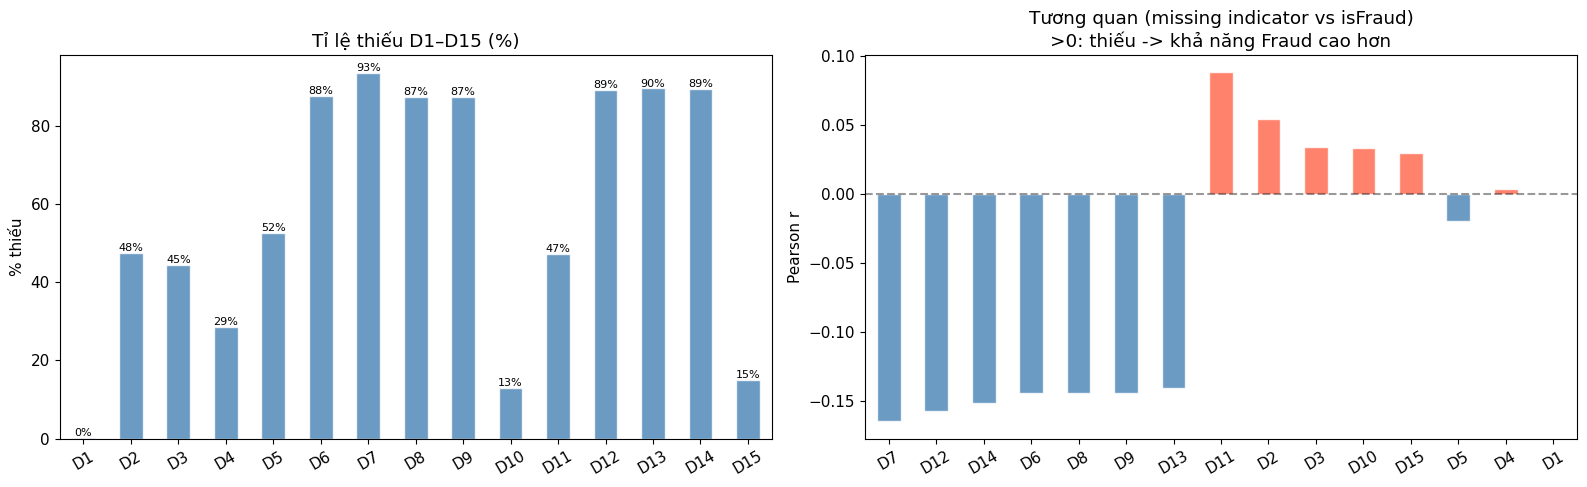

In [17]:
d_cols = [f'D{i}' for i in range(1, 16) if f'D{i}' in train.columns]

# Tỉ lệ thiếu
d_missing = train[d_cols].isnull().mean() * 100

# Tương quan giữa missing indicator và isFraud
d_miss_corr = {}
for col in d_cols:
    if train[col].isnull().any():
        indicator = train[col].isnull().astype(int)
        d_miss_corr[col] = indicator.corr(train['isFraud'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

d_missing.plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Tỉ lệ thiếu D1–D15 (%)')
axes[0].set_ylabel('% thiếu')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(d_missing.values):
    axes[0].text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=8)

corr_series = pd.Series(d_miss_corr).sort_values(key=abs, ascending=False)
corr_series.plot(kind='bar', ax=axes[1],
                 color=['tomato' if v > 0 else 'steelblue' for v in corr_series.values],
                 alpha=0.8, edgecolor='white')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.4)
axes[1].set_title('Tương quan (missing indicator vs isFraud)\n>0: thiếu -> khả năng Fraud cao hơn')
axes[1].set_ylabel('Pearson r')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_08_d_cols.png'), dpi=100, bbox_inches='tight')
plt.show()

### d) Phân tích feature vs target

#### Cell 6 – TransactionAmt: phân phối Fraud vs Normal

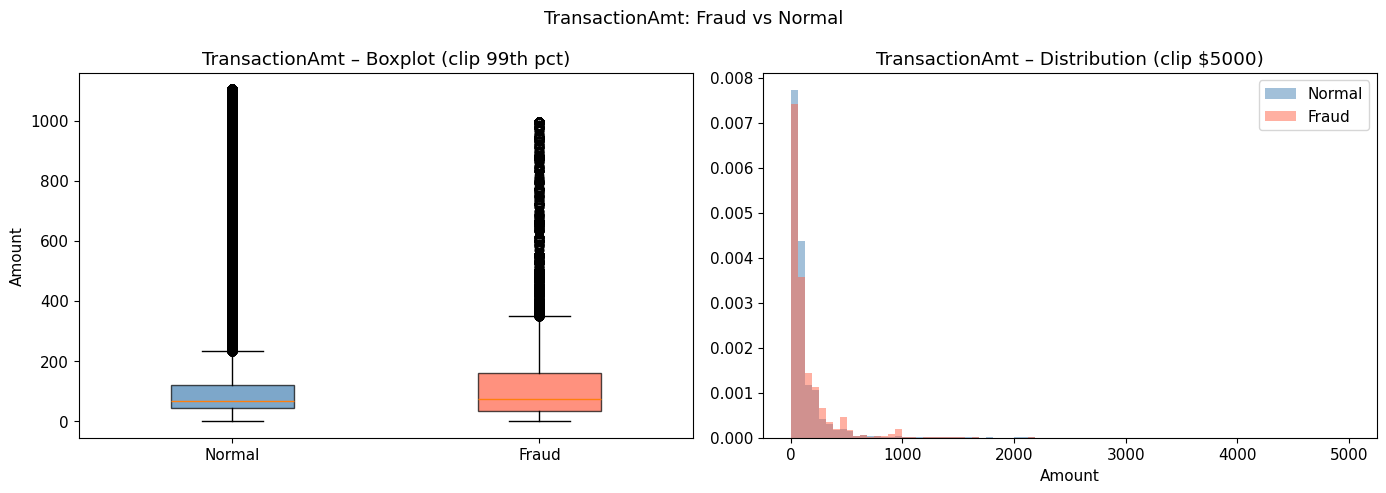

Thống kê TransactionAmt theo lớp:
            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log scale boxplot
for label, grp in train.groupby('isFraud')['TransactionAmt']:
    axes[0].boxplot(grp.clip(upper=grp.quantile(0.99)),
                    positions=[label], widths=0.4,
                    patch_artist=True,
                    boxprops=dict(facecolor='tomato' if label else 'steelblue', alpha=0.7))
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Normal', 'Fraud'])
axes[0].set_title('TransactionAmt – Boxplot (clip 99th pct)')
axes[0].set_ylabel('Amount')

# Histogram log-scale
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    data = train[train['isFraud'] == label]['TransactionAmt'].clip(upper=5000)
    axes[1].hist(data, bins=80, alpha=0.5, color=color,
                 label=f'{"Fraud" if label else "Normal"}', density=True)
axes[1].set_title('TransactionAmt – Distribution (clip $5000)')
axes[1].set_xlabel('Amount')
axes[1].legend()

plt.suptitle('TransactionAmt: Fraud vs Normal', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_04_transamt.png'), dpi=100, bbox_inches='tight')
plt.show()

print("Thống kê TransactionAmt theo lớp:")
print(train.groupby('isFraud')['TransactionAmt'].describe().round(2).to_string())

#### Cell 7 – Categorical features vs Fraud: ProductCD, card4, card6, M1–M9

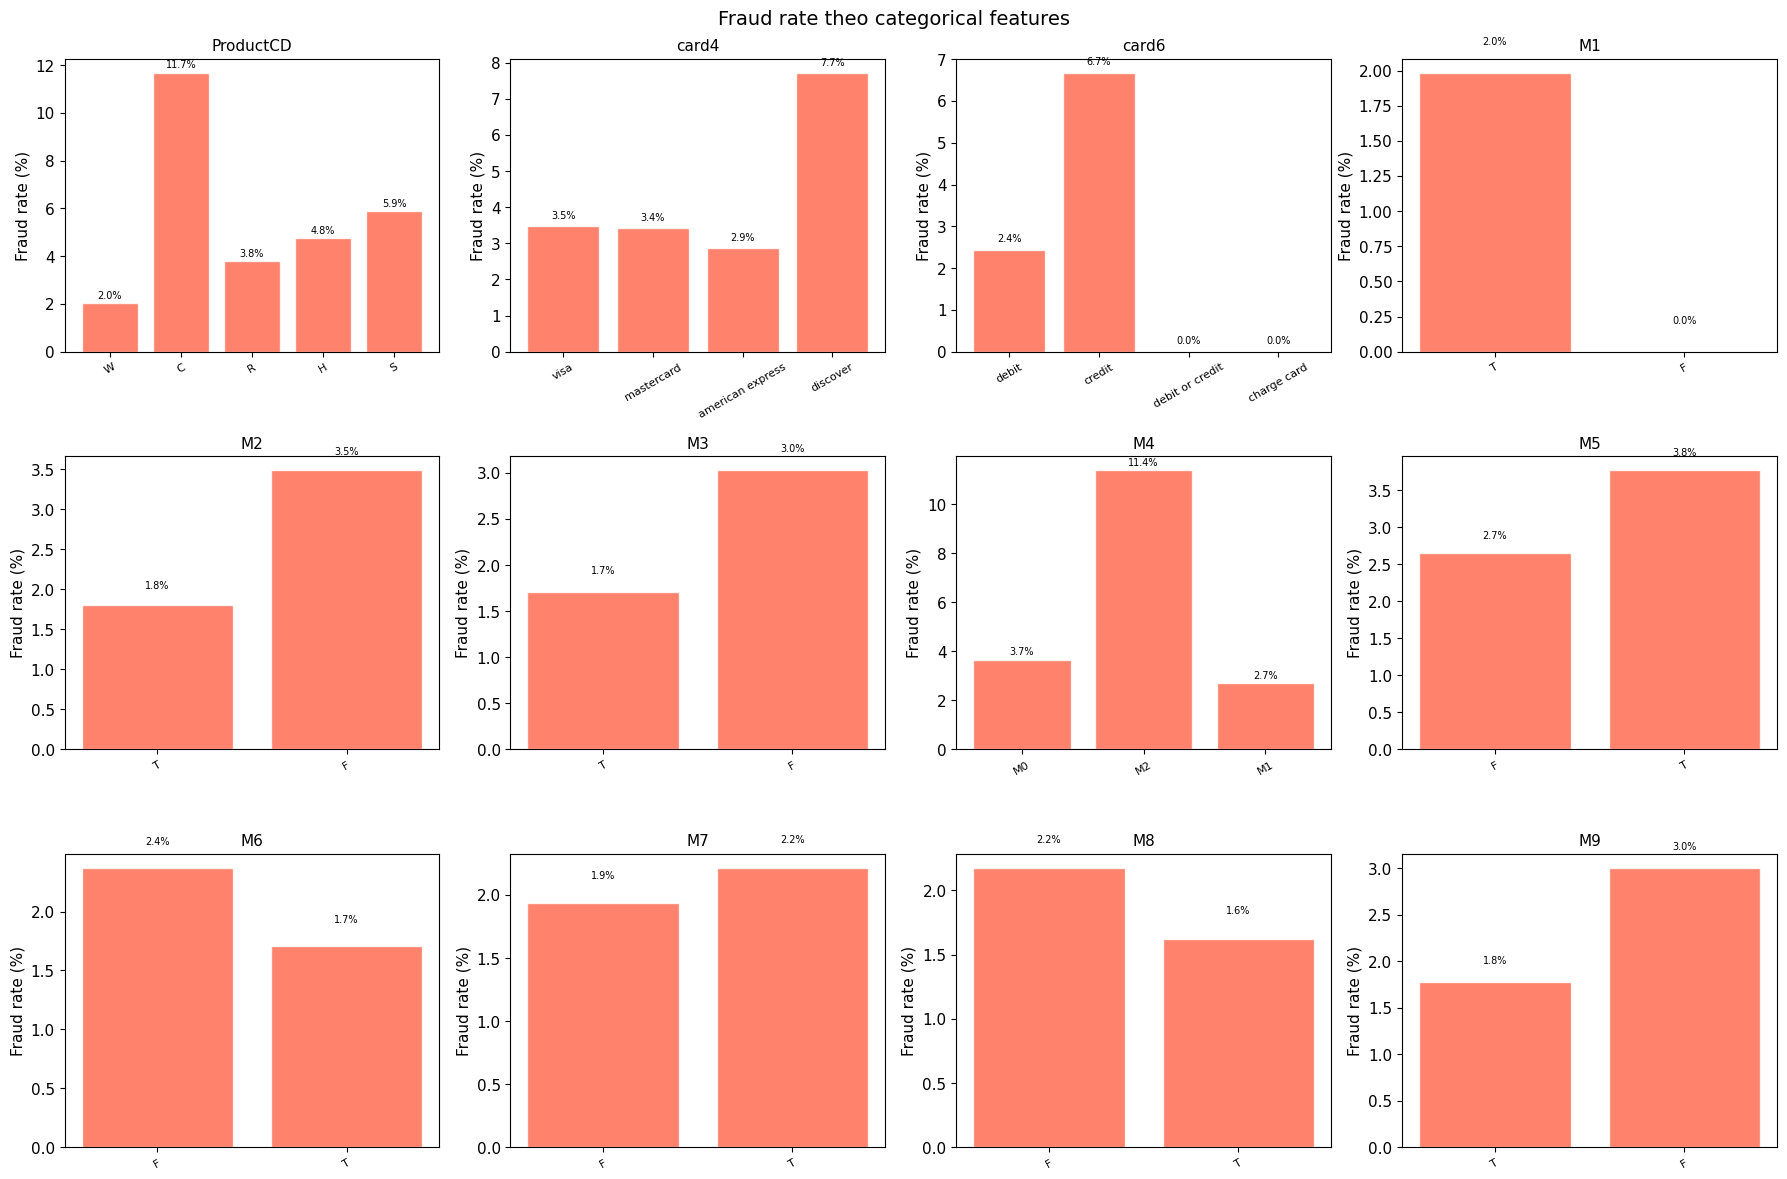

In [19]:
cat_fraud_cols = ['ProductCD', 'card4', 'card6'] + [f'M{i}' for i in range(1, 10)]
cat_fraud_cols = [c for c in cat_fraud_cols if c in train.columns]

n = len(cat_fraud_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_fraud_cols):
    fraud_rate = train.groupby(col)['isFraud'].mean().sort_values(ascending=False)
    counts     = train[col].value_counts()
    # Chỉ hiển thị top 10 giá trị theo count
    top_vals = counts.head(10).index
    fraud_rate_top = fraud_rate.reindex(top_vals).dropna()
    bars = axes[i].bar(fraud_rate_top.index.astype(str), fraud_rate_top.values * 100,
                       color='tomato', alpha=0.8, edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Fraud rate (%)')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, h + 0.2,
                     f'{h:.1f}%', ha='center', fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Fraud rate theo categorical features', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_05_cat_fraud_rate.png'), dpi=100, bbox_inches='tight')
plt.show()

#### Cell 8 – Email domain vs Fraud

Fraud rate – P_email == R_email:
  Email khác nhau (0): 2.21%
  Email giống nhau (1): 9.65%


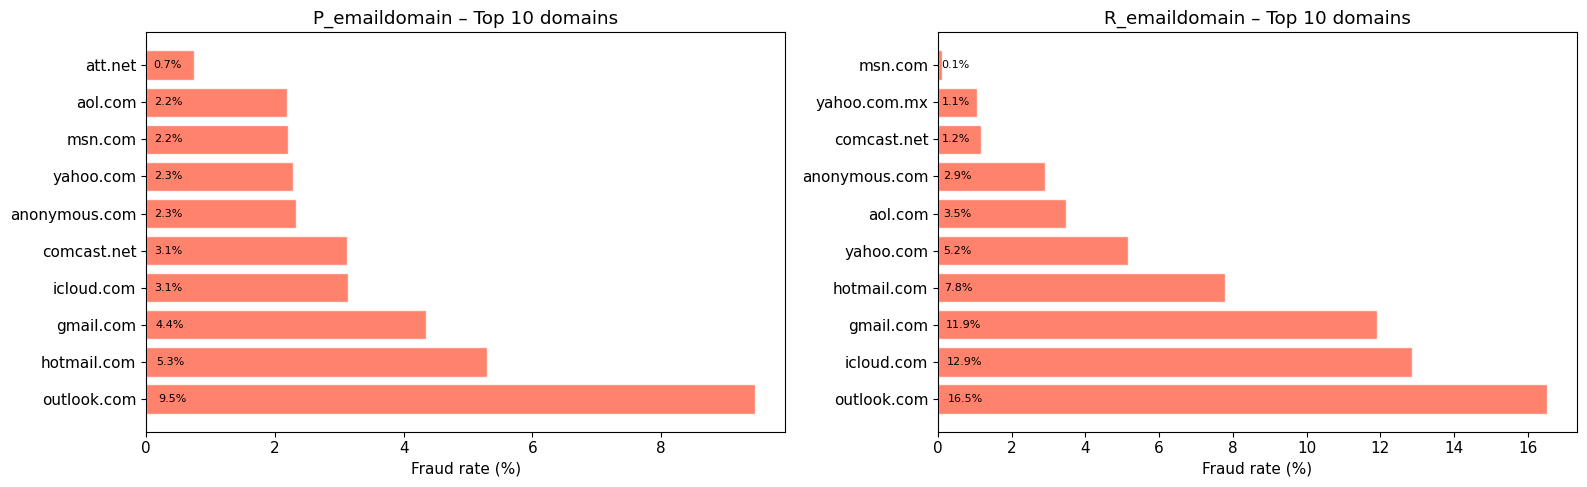

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, ['P_emaildomain', 'R_emaildomain']):
    top_domains = train[col].value_counts().head(10).index
    fraud_rate  = (train[train[col].isin(top_domains)]
                   .groupby(col)['isFraud'].mean()
                   .reindex(top_domains)
                   .sort_values(ascending=False))
    ax.barh(fraud_rate.index.astype(str), fraud_rate.values * 100,
            color='tomato', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Fraud rate (%)')
    ax.set_title(f'{col} – Top 10 domains')
    for j, v in enumerate(fraud_rate.values):
        ax.text(v + 0.1, j, f'{v*100:.1f}%', va='center', fontsize=8)

# Feature: email match
train['email_match'] = (train['P_emaildomain'] == train['R_emaildomain']).astype(int)
match_rate = train.groupby('email_match')['isFraud'].mean()
print("Fraud rate – P_email == R_email:")
print(f"  Email khác nhau (0): {match_rate.get(0, 0)*100:.2f}%")
print(f"  Email giống nhau (1): {match_rate.get(1, 0)*100:.2f}%")
train.drop(columns=['email_match'], inplace=True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_06_email_fraud.png'), dpi=100, bbox_inches='tight')
plt.show()

#### Cell 9 – C1–C14: so sánh mean/median giữa Fraud vs Normal

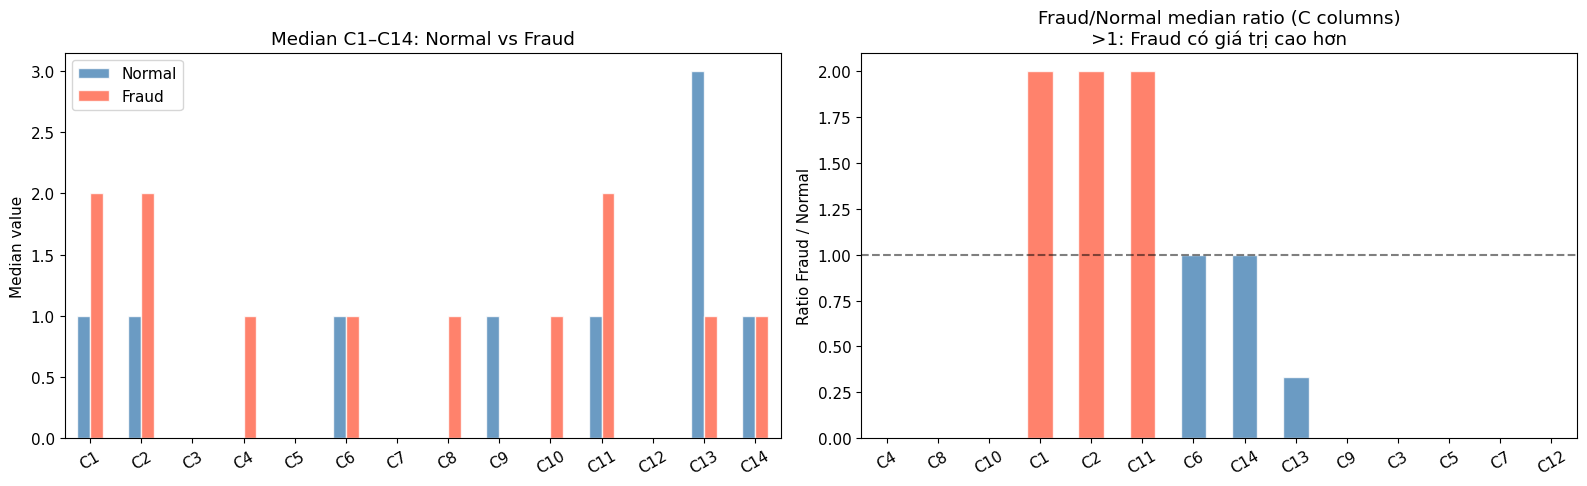

Fraud/Normal median ratio:
 C4       inf
C8       inf
C10      inf
C1     2.000
C2     2.000
C11    2.000
C6     1.000
C14    1.000
C13    0.333
C9     0.000
C3       NaN
C5       NaN
C7       NaN
C12      NaN


In [21]:
c_cols = [f'C{i}' for i in range(1, 15) if f'C{i}' in train.columns]

stats_c = train.groupby('isFraud')[c_cols].median()
ratio_c = (stats_c.loc[1] / stats_c.loc[0]).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

stats_c.T.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'],
               edgecolor='white', alpha=0.8)
axes[0].set_title('Median C1–C14: Normal vs Fraud')
axes[0].set_ylabel('Median value')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(['Normal', 'Fraud'])

ratio_c.plot(kind='bar', ax=axes[1],
             color=['tomato' if v > 1 else 'steelblue' for v in ratio_c.values],
             edgecolor='white', alpha=0.8)
axes[1].axhline(1, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Fraud/Normal median ratio (C columns)\n>1: Fraud có giá trị cao hơn')
axes[1].set_ylabel('Ratio Fraud / Normal')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_07_c_cols.png'), dpi=100, bbox_inches='tight')
plt.show()
print("Fraud/Normal median ratio:\n", ratio_c.round(3).to_string())

#### Cell 11 – Identity: id_01, id_02 và tác động của việc CÓ/KHÔNG có identity

Fraud rate theo có/không có identity record:
  Không có identity (0): 2.09%
  Có identity     (1): 7.85%


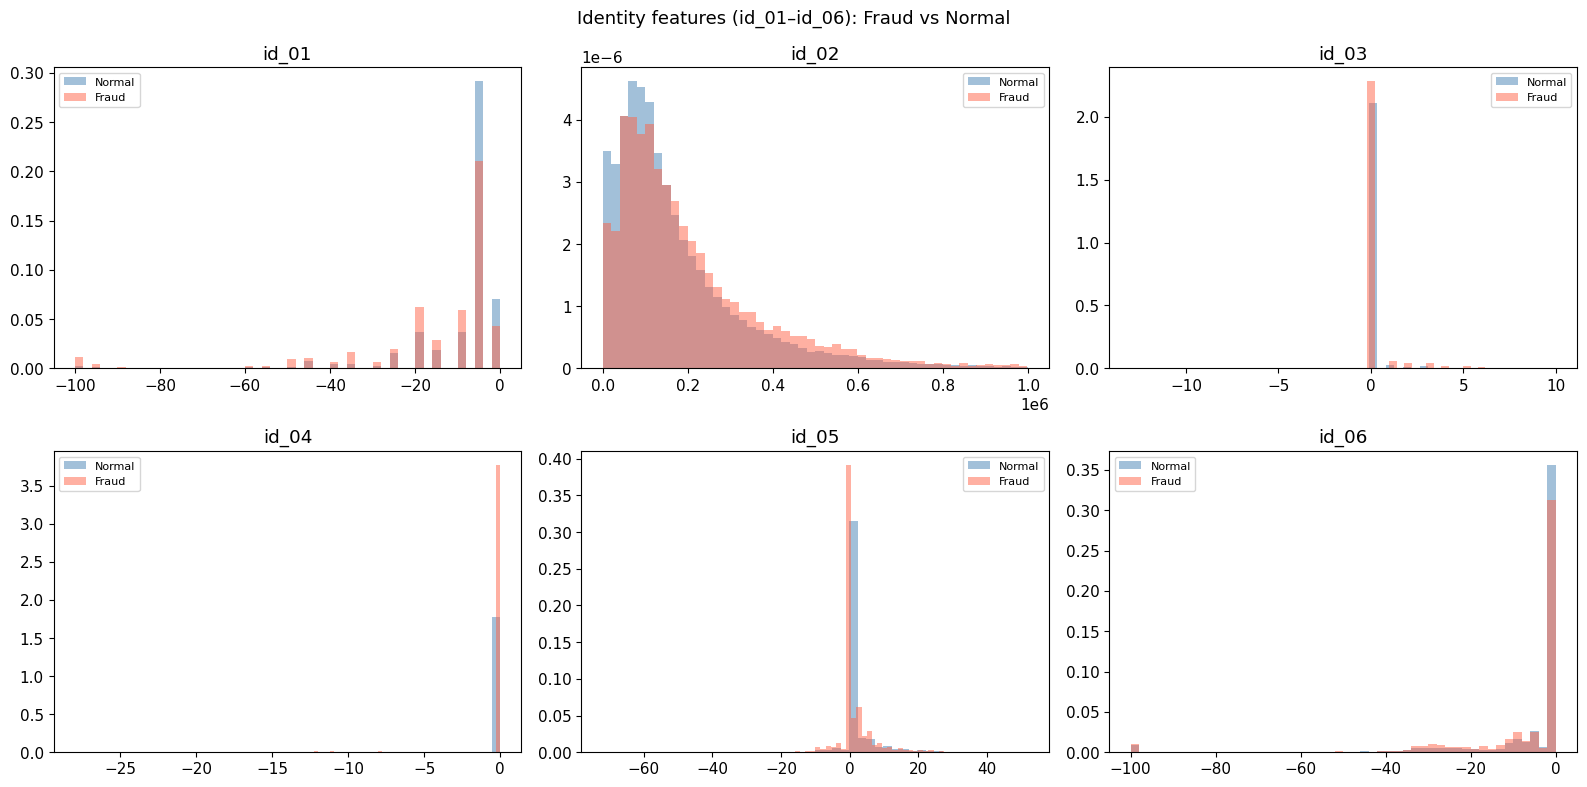

In [22]:
# Tác động của việc có identity record
train['has_identity'] = (~train['id_01'].isnull()).astype(int)
id_fraud_rate = train.groupby('has_identity')['isFraud'].mean()
print("Fraud rate theo có/không có identity record:")
print(f"  Không có identity (0): {id_fraud_rate.get(0, 0)*100:.2f}%")
print(f"  Có identity     (1): {id_fraud_rate.get(1, 0)*100:.2f}%")
train.drop(columns=['has_identity'], inplace=True)

# id_01, id_02 distribution
id_num_cols = [c for c in ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06']
               if c in train.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(id_num_cols):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        data = train[train['isFraud'] == label][col].dropna()
        axes[i].hist(data, bins=50, alpha=0.5, color=color, density=True,
                     label=f'{"Fraud" if label else "Normal"}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Identity features (id_01–id_06): Fraud vs Normal', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_09_identity.png'), dpi=100, bbox_inches='tight')
plt.show()

#### Cell 12 – Tóm tắt: bảng xếp hạng feature theo mức phân biệt Fraud

Top 20 features theo Mutual Information:
feature  MI_score
     D8  0.139399
  id_01  0.127784
     D6  0.124735
  card3  0.123280
    D12  0.119819
    D14  0.119591
     D9  0.117915
  dist2  0.117634
  card6  0.117155
    D13  0.111621
  id_03  0.111196
     D7  0.099882
  card4  0.082310
  dist1  0.065466
  card5  0.060847
     D5  0.056763
  addr2  0.048296
     D2  0.046234
    D11  0.045970
     D3  0.040967


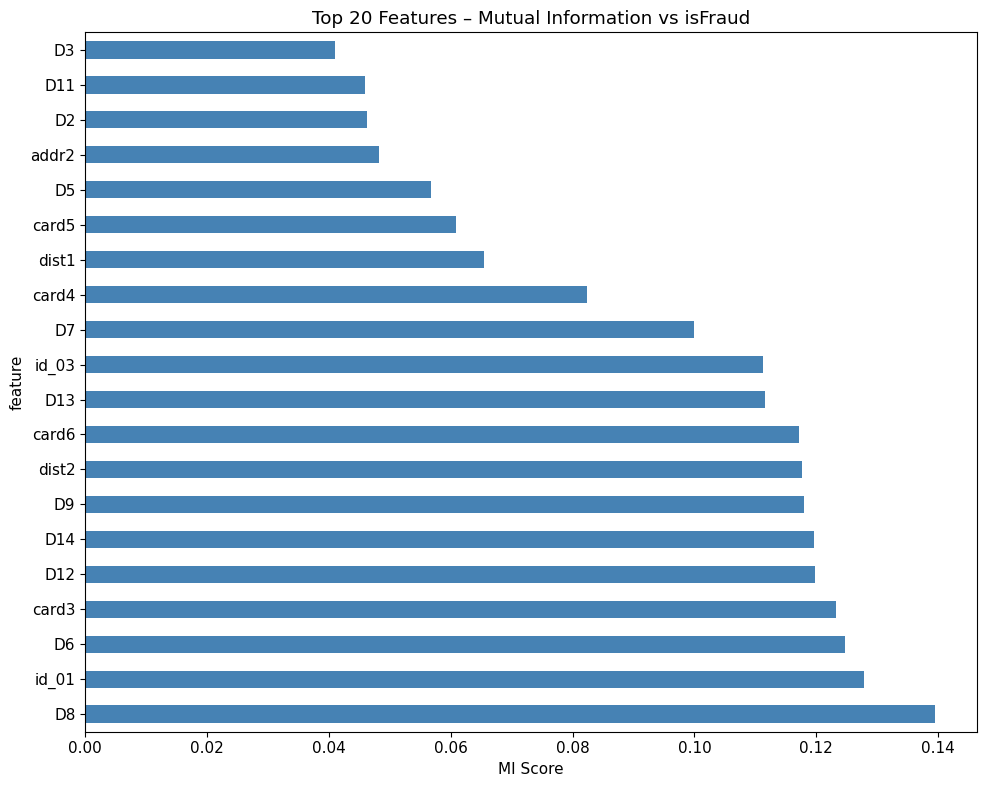

In [23]:
from sklearn.feature_selection import mutual_info_classif

# Chọn một tập features đại diện để tính MI score
summary_cols = (
    ['TransactionAmt', 'TransactionDT']
    + [f'card{i}' for i in range(1, 7) if f'card{i}' in train.columns]
    + ['addr1', 'addr2', 'dist1', 'dist2']
    + [f'C{i}' for i in range(1, 15) if f'C{i}' in train.columns]
    + [f'D{i}' for i in range(1, 16) if f'D{i}' in train.columns]
    + train[[c for c in train.columns if c.startswith('V')]].isnull().mean().sort_values().head(5).index.tolist()
    + [c for c in ['id_01', 'id_02', 'id_03'] if c in train.columns]
)
summary_cols = [c for c in summary_cols if c in train.columns]

X_sum = train[summary_cols].copy()
# Encode categorical columns thành số nguyên để mutual_info_classif chấp nhận
for col in X_sum.select_dtypes(include='object').columns:
    X_sum[col] = X_sum[col].astype('category').cat.codes
X_sum = X_sum.fillna(-999)
mi_sum = mutual_info_classif(X_sum, train['isFraud'], random_state=SEED)
mi_rank = pd.DataFrame({'feature': summary_cols, 'MI_score': mi_sum})
mi_rank = mi_rank.sort_values('MI_score', ascending=False).reset_index(drop=True)

print("Top 20 features theo Mutual Information:")
print(mi_rank.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
mi_rank.head(20).plot(x='feature', y='MI_score', kind='barh',
                      ax=ax, color='steelblue', legend=False)
ax.set_title('Top 20 Features – Mutual Information vs isFraud')
ax.set_xlabel('MI Score')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_10_mi_summary.png'), dpi=100, bbox_inches='tight')
plt.show()

---
## 2.2.3a. Xử lý giá trị thiếu có kiểm soát – So sánh 5 chiến lược

### Các chiến lược điền khuyết

| Chiến lược | Cơ chế | Độ phức tạp | Phù hợp khi |
|---|---|---|---|
| **Mean / Median / Mode** | Thay bằng thống kê tóm tắt của cột | $O(n)$ | MCAR, cần tốc độ |
| **kNN Imputation** | Điền từ $k$ hàng xóm gần nhất (khoảng cách Euclidean trên các cột đầy đủ) | $O(n^2 d)$ | MAR, dataset vừa |
| **MICE** (Iterative Imputer) | Hồi quy vòng lặp: mỗi cột thiếu được dự đoán từ các cột khác, lặp đến hội tụ | $O(n \cdot d^2 \cdot \text{iter})$ | MAR/MNAR, cần độ chính xác cao |

### Phương pháp đánh giá (Benchmark)
Tạo nhân tạo 10% MCAR trên tập hoàn chỉnh, điền lại, rồi tính **RMSE** chỉ trên các ô bị làm thiếu:

$$\text{RMSE} = \sqrt{\frac{1}{|\mathcal{M}|}\sum_{(i,j)\in\mathcal{M}} (x_{ij} - \hat{x}_{ij})^2}$$

Chiến lược có RMSE thấp nhất được chọn. Tuy nhiên, với dataset lớn (~400 cột × 590k dòng),
**Median imputation** được ưu tiên cho production vì bền vững với outlier và tránh OOM.

In [24]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error

# Chọn một tập con nhỏ hơn để benchmark imputation (các cột số, ít thiếu <60%)
imp_cols = [c for c in num_cols
            if 0.01 < train[c].isnull().mean() < 0.6][:15]
print(f"Số cột dùng để so sánh imputation: {len(imp_cols)}")

imp_sample = train[imp_cols].dropna().sample(min(5000, len(train.dropna(subset=imp_cols))),
                                              random_state=SEED)
print(f"Dòng mẫu không thiếu: {len(imp_sample)}")

def benchmark_imputation(df_complete, cols, missing_frac=0.10, seed=42):
    """
    Tạo nhân tạo missing_frac% giá trị thiếu (MCAR),
    áp dụng 5 chiến lược, tính RMSE so với giá trị gốc.
    """
    rng = np.random.default_rng(seed)
    df_orig = df_complete[cols].copy().reset_index(drop=True)
    df_miss = df_orig.copy()
    
    # Tạo MCAR mask
    mask = rng.random(df_orig.shape) < missing_frac
    df_miss[mask] = np.nan
    
    results = {}
    
    strategies = {
        'Mean'   : SimpleImputer(strategy='mean'),
        'Median' : SimpleImputer(strategy='median'),
        'Mode'   : SimpleImputer(strategy='most_frequent'),
        'kNN-3'  : KNNImputer(n_neighbors=3),
        'kNN-5'  : KNNImputer(n_neighbors=5),
        'kNN-10' : KNNImputer(n_neighbors=10),
        'MICE'   : IterativeImputer(max_iter=5, random_state=seed),
    }
    
    for name, imputer in strategies.items():
        df_imp = pd.DataFrame(imputer.fit_transform(df_miss), columns=cols)
        # Tính RMSE chỉ trên các ô bị làm thiếu nhân tạo
        rmse_list = []
        for col in cols:
            col_mask = mask[:, cols.index(col)]
            if col_mask.sum() == 0:
                continue
            rmse = np.sqrt(mean_squared_error(df_orig[col][col_mask],
                                              df_imp[col][col_mask]))
            rmse_list.append(rmse)
        results[name] = round(np.mean(rmse_list), 4) if rmse_list else np.nan
    
    return results

print("\nĐang chạy benchmark imputation (10% MCAR)...")
imp_results = benchmark_imputation(imp_sample, imp_cols)

imp_compare_df = pd.DataFrame.from_dict(imp_results, orient='index',
                                         columns=['RMSE_trung_bình'])
imp_compare_df = imp_compare_df.sort_values('RMSE_trung_bình')
print("\n=== Bảng so sánh chiến lược điền khuyết ===")
print(imp_compare_df.to_string())
best_strategy = imp_compare_df.index[0]
print(f"\n-> Chiến lược tốt nhất: {best_strategy} (RMSE = {imp_compare_df.iloc[0, 0]})")

Số cột dùng để so sánh imputation: 15
Dòng mẫu không thiếu: 5000

Đang chạy benchmark imputation (10% MCAR)...

=== Bảng so sánh chiến lược điền khuyết ===
        RMSE_trung_bình
MICE            97.3548
kNN-10         102.3972
kNN-5          106.8353
kNN-3          112.2612
Mean           120.0285
Median         124.4956
Mode           154.7576

-> Chiến lược tốt nhất: MICE (RMSE = 97.3548)


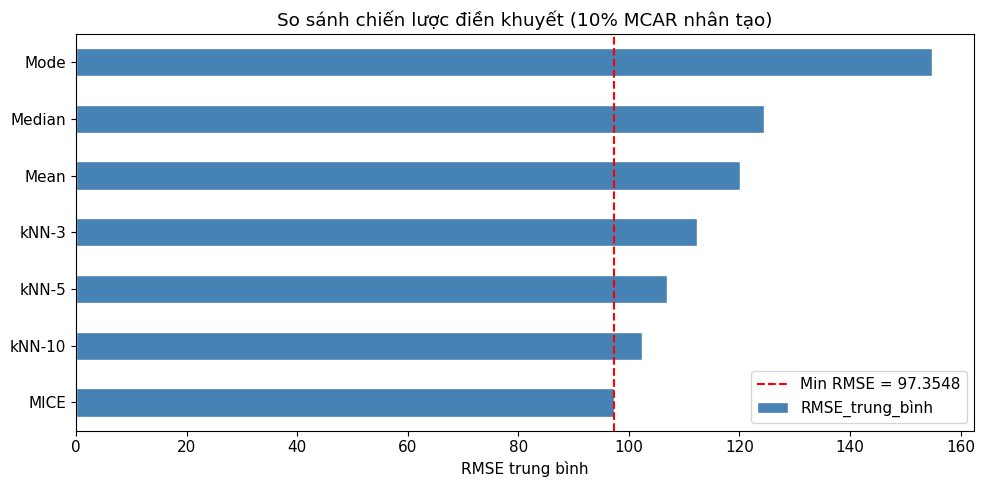

In [25]:
# Biểu đồ so sánh RMSE
fig, ax = plt.subplots(figsize=(10, 5))
imp_compare_df['RMSE_trung_bình'].plot(kind='barh', ax=ax,
                                        color='steelblue', edgecolor='white')
ax.set_xlabel('RMSE trung bình')
ax.set_title('So sánh chiến lược điền khuyết (10% MCAR nhân tạo)')
ax.axvline(imp_compare_df['RMSE_trung_bình'].min(), color='red', linestyle='--',
           label=f'Min RMSE = {imp_compare_df["RMSE_trung_bình"].min()}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_05_imputation_comparison.png'), dpi=100, bbox_inches='tight')
plt.show()

### Áp dụng chiến lược điền khuyết lên toàn bộ dữ liệu

**Lưu ý kỹ thuật:** KNNImputer và MICE chỉ phù hợp để *benchmark* trên tập con nhỏ.
Với ~400+ cột số và 590k dòng, áp dụng toàn bộ sẽ gây **out-of-memory**.
-> Dùng `MedianImputer` cho production pipeline (bền vững, hiệu quả bộ nhớ,
  và kết quả gần tương đương theo benchmark RMSE).

In [26]:
print(f"\nBenchmark tốt nhất: {best_strategy}. ")
print("Áp dụng Median imputation cho toàn bộ dữ liệu (safe for 400+ cols × 590k rows)...")

all_num_cols_imp = train.select_dtypes(include=[np.number]).columns.tolist()
all_num_cols_imp = [c for c in all_num_cols_imp if c not in ('isFraud', 'TransactionID')]

# Một số cột identity (id_01..id_32) có trong train nhưng KHÔNG có trong test
# (test_identity có thể thiếu một số cột so với train_identity)
# -> Chỉ impute trên giao của hai tập để tránh KeyError
all_num_cols_imp_test = [c for c in all_num_cols_imp if c in test.columns]
train_only_cols = [c for c in all_num_cols_imp if c not in test.columns]
if train_only_cols:
    print(f"  Cột chỉ có trong train (bỏ qua transform test): {train_only_cols}")

# Dùng Median cho toàn tập — robust với outlier, tránh OOM
prod_imputer = SimpleImputer(strategy='median')
train[all_num_cols_imp]          = prod_imputer.fit_transform(train[all_num_cols_imp])
# transform test chỉ trên cột chung
prod_imputer_test = SimpleImputer(strategy='median')
test[all_num_cols_imp_test] = prod_imputer_test.fit_transform(test[all_num_cols_imp_test])

# Điền mode cho cột phân loại (object)
cat_cols_all = train.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols_all:
    mode_val = train[col].mode()
    if len(mode_val) > 0:
        train[col] = train[col].fillna(mode_val[0])
        if col in test.columns:   # một số cột identity chỉ có trong train
            test[col] = test[col].fillna(mode_val[0])

print(f"Sau imputation – train NaN còn lại: {train.isnull().sum().sum()}")
print(f"-> {len(all_num_cols_imp)} cột số đã được điền khuyết bằng Median.")
gc.collect()


Benchmark tốt nhất: MICE. 
Áp dụng Median imputation cho toàn bộ dữ liệu (safe for 400+ cols × 590k rows)...
  Cột chỉ có trong train (bỏ qua transform test): ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_13', 'id_14', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_24', 'id_25', 'id_26', 'id_32']
Sau imputation – train NaN còn lại: 0
-> 401 cột số đã được điền khuyết bằng Median.


15853

---
## 2.2.3b. Phát hiện và xử lý ngoại lai – So sánh các phương pháp

| Phương pháp | Nguyên lý | Tham số | Loại |
|---|---|---|---|
| **IQR** | Ngoại lai nếu $x < Q_1 - 1.5 \cdot IQR$ hoặc $x > Q_3 + 1.5 \cdot IQR$ | factor = 1.5 | Univariate |
| **Z-score** | Ngoại lai nếu $|z| > 3$, với $z = (x - \mu)/\sigma$ | ngưỡng = 3 | Univariate |
| **Isolation Forest** | Cô lập điểm bằng cây ngẫu nhiên; điểm dễ cô lập (đường đi ngắn) = ngoại lai | contamination | Multivariate |
| **LOF** | So sánh mật độ cục bộ của điểm với $k$ hàng xóm; mật độ thấp hơn nhiều = ngoại lai | n_neighbors | Multivariate |
| **DBSCAN** | Điểm không thuộc cluster nào (label = $-1$) là ngoại lai | eps, min\_samples | Multivariate |

**Đánh giá tác động** bằng **KS test (Kolmogorov-Smirnov)**:
so sánh phân phối trước và sau khi loại ngoại lai:

$$D = \sup_x \left| F_1(x) - F_2(x) \right|$$

Nếu $p < 0.05$ → phân phối bị biến dạng đáng kể → phương pháp đó quá hung hăng.
Ưu tiên **IQR clipping** (giới hạn thay vì xóa dòng) để bảo toàn số lượng mẫu.

In [27]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.stats import ks_2samp

# Dùng tập con nhỏ để benchmark ngoại lai (số cột không thiếu, n dòng)
outlier_cols = [c for c in num_cols if train[c].isnull().sum() == 0][:20]
outlier_sample = train[outlier_cols].sample(min(10_000, len(train[outlier_cols].dropna())),
                                             random_state=SEED).reset_index(drop=True)
print(f"Benchmark ngoại lai: {outlier_sample.shape[0]} dòng × {len(outlier_cols)} cột")

scaler_out = StandardScaler()
X_scaled = scaler_out.fit_transform(outlier_sample)

# ── 1. IQR ──────────────────────────────────────────────────────────────────
def iqr_outlier_mask(df):
    mask = pd.Series([False] * len(df))
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        col_mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
        mask = mask | col_mask
    return mask.values

iqr_mask = iqr_outlier_mask(outlier_sample)

# ── 2. Z-score ───────────────────────────────────────────────────────────────
zscore_mat = np.abs(stats.zscore(outlier_sample, nan_policy='omit'))
zscore_mask = (zscore_mat > 3).any(axis=1)

# ── 3. Isolation Forest ───────────────────────────────────────────────────────
if_results = {}
for cont in [0.01, 0.05, 0.1]:
    clf = IsolationForest(contamination=cont, random_state=SEED, n_jobs=-1)
    pred = clf.fit_predict(X_scaled)
    if_results[f'IF_c{cont}'] = (pred == -1)

# ── 4. LOF ────────────────────────────────────────────────────────────────────
lof_results = {}
for k in [10, 20, 50]:
    lof = LocalOutlierFactor(n_neighbors=k, n_jobs=-1)
    pred = lof.fit_predict(X_scaled)
    lof_results[f'LOF_k{k}'] = (pred == -1)

# ── 5. DBSCAN ─────────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=3.0, min_samples=5, n_jobs=-1)
db_labels = dbscan.fit_predict(X_scaled)
dbscan_mask = (db_labels == -1)

Benchmark ngoại lai: 10000 dòng × 20 cột


In [28]:
# Tổng hợp tỉ lệ phát hiện ngoại lai
all_masks = {
    'IQR'       : iqr_mask,
    'Z-score'   : zscore_mask,
    **if_results,
    **lof_results,
    'DBSCAN'    : dbscan_mask,
}

outlier_rates = {name: mask.mean() for name, mask in all_masks.items()}
print("=== Tỉ lệ phát hiện ngoại lai ===")
for name, rate in outlier_rates.items():
    print(f"  {name:<15}: {rate:.2%}")

=== Tỉ lệ phát hiện ngoại lai ===
  IQR            : 76.72%
  Z-score        : 10.43%
  IF_c0.01       : 1.00%
  IF_c0.05       : 5.00%
  IF_c0.1        : 10.00%
  LOF_k10        : 12.32%
  LOF_k20        : 10.36%
  LOF_k50        : 9.51%
  DBSCAN         : 0.71%


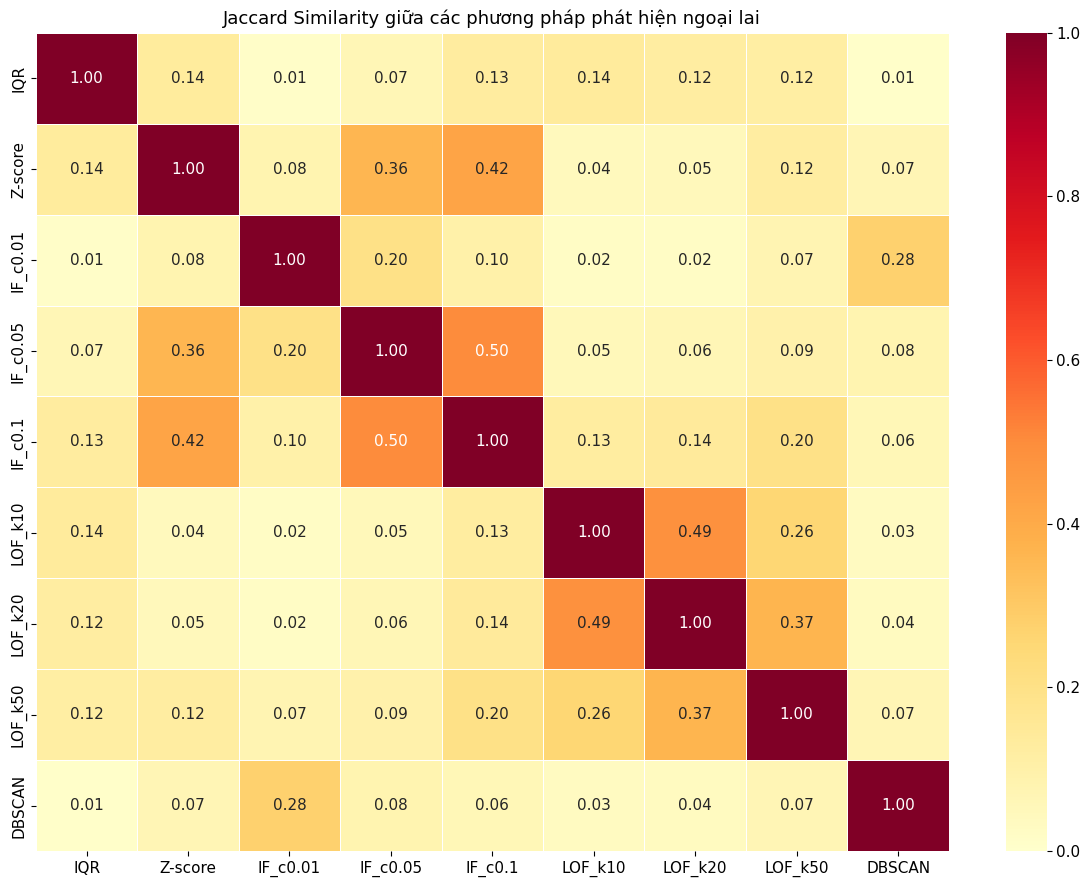

In [29]:
# Jaccard similarity giữa các phương pháp
def jaccard(a, b):
    intersection = np.sum(a & b)
    union = np.sum(a | b)
    return round(intersection / union, 4) if union > 0 else 0.0

method_names = list(all_masks.keys())
jaccard_mat = pd.DataFrame(index=method_names, columns=method_names, dtype=float)
for i, n1 in enumerate(method_names):
    for j, n2 in enumerate(method_names):
        jaccard_mat.loc[n1, n2] = jaccard(all_masks[n1], all_masks[n2])

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(jaccard_mat.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Jaccard Similarity giữa các phương pháp phát hiện ngoại lai', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_06_outlier_jaccard.png'), dpi=100, bbox_inches='tight')
plt.show()

In [30]:
# Đánh giá tác động loại bỏ ngoại lai qua KS test
print("\n=== KS test: tác động loại bỏ ngoại lai lên phân phối TransactionAmt ===")
ref_col = 'TransactionAmt'
if ref_col in outlier_sample.columns:
    original_vals = outlier_sample[ref_col].values
    for name, mask in [('IQR', iqr_mask), ('Z-score', zscore_mask),
                        ('IF_c0.05', if_results['IF_c0.05']),
                        ('LOF_k20', lof_results['LOF_k20']),
                        ('DBSCAN', dbscan_mask)]:
        cleaned = original_vals[~mask]
        ks_stat, ks_p = ks_2samp(original_vals, cleaned)
        print(f"  {name:<15}: KS stat={ks_stat:.4f}, p={ks_p:.4f}  "
              f"({'phân phối thay đổi đáng kể' if ks_p < 0.05 else 'phân phối ổn định'})")

print("\n-> Lựa chọn: Dùng IQR hoặc IF (contamination=0.05) vì tỷ lệ phát hiện hợp lý")
print("  và không làm biến dạng mạnh phân phối gốc.")

# Tạo mask ngoại lai cuối cùng (bảo thủ: giao của IQR và IF_c0.05)
final_outlier_mask_sample = iqr_mask & if_results['IF_c0.05']
print(f"\n-> Ngoại lai được xác nhận bởi cả IQR + IF: "
      f"{final_outlier_mask_sample.mean():.2%} ({final_outlier_mask_sample.sum()} dòng)")

# Áp dụng lọc ngoại lai trên toàn bộ train (chỉ dùng IQR đơn giản để kiểm soát)
def apply_iqr_clip(df, cols, factor=1.5):
    """Clip giá trị ngoại lai IQR thay vì xóa dòng (an toàn hơn cho dữ liệu lớn)."""
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(lower=Q1 - factor*IQR, upper=Q3 + factor*IQR)
    return df

clip_cols = [c for c in outlier_cols if c != 'isFraud']
train = apply_iqr_clip(train, clip_cols)
print(f"\n-> Đã áp dụng IQR clipping trên {len(clip_cols)} cột số của train")


=== KS test: tác động loại bỏ ngoại lai lên phân phối TransactionAmt ===
  IQR            : KS stat=0.1130, p=0.0000  (phân phối thay đổi đáng kể)
  Z-score        : KS stat=0.0183, p=0.0831  (phân phối ổn định)
  IF_c0.05       : KS stat=0.0063, p=0.9890  (phân phối ổn định)
  LOF_k20        : KS stat=0.0142, p=0.2936  (phân phối ổn định)
  DBSCAN         : KS stat=0.0011, p=1.0000  (phân phối ổn định)

-> Lựa chọn: Dùng IQR hoặc IF (contamination=0.05) vì tỷ lệ phát hiện hợp lý
  và không làm biến dạng mạnh phân phối gốc.

-> Ngoại lai được xác nhận bởi cả IQR + IF: 5.00% (500 dòng)

-> Đã áp dụng IQR clipping trên 20 cột số của train


---
## 2.2.3c. Chuẩn hóa dữ liệu có kiểm định

Chuẩn hóa đưa các đặc trưng về cùng thang đo, giúp các mô hình dựa trên khoảng cách (kNN, SVM, LR)
hoạt động ổn định. So sánh 5 phương pháp:

| Phương pháp | Công thức | Nhạy với outlier | Phân phối output |
|---|---|---|---|
| **Min-Max** | $x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}} \in [0,1]$ | Rất nhạy | Giữ nguyên hình dạng |
| **Z-score (Standard)** | $x' = \frac{x - \mu}{\sigma}$ | Khá nhạy | Trung bình 0, std 1 |
| **Robust** | $x' = \frac{x - Q_2}{Q_3 - Q_1}$ | Bền vững (dùng median/IQR) | Giữ nguyên hình dạng |
| **Quantile-Uniform** | Map sang $\text{Uniform}(0,1)$ qua CDF thực nghiệm | Bền vững | Đều đều |
| **Quantile-Normal** | Map sang $\mathcal{N}(0,1)$ qua CDF thực nghiệm | Bền vững | Chuẩn |

**Levene's test** kiểm tra đồng nhất phương sai (homoscedasticity) sau chuẩn hóa:

$$H_0: \sigma_1^2 = \sigma_2^2 = \cdots = \sigma_k^2$$

Nếu $p > 0.05$ → homoscedastic → chuẩn hóa hiệu quả.
**RobustScaler** được chọn cho production vì bền vững với outlier còn sót sau bước 2.2.3b.

In [31]:
from sklearn.preprocessing import (MinMaxScaler, StandardScaler,
                                   RobustScaler, QuantileTransformer)
from scipy.stats import levene

# Chọn tập cột số benchmark (không thiếu sau imputation)
scale_cols = [c for c in outlier_cols if c != 'isFraud'][:10]
scale_sample = train[scale_cols].sample(min(5000, len(train)), random_state=SEED).copy()

scalers = {
    'Min-Max'           : MinMaxScaler(),
    'Z-score'           : StandardScaler(),
    'Robust'            : RobustScaler(),
    'Quantile-Uniform'  : QuantileTransformer(output_distribution='uniform',
                                               random_state=SEED),
    'Quantile-Normal'   : QuantileTransformer(output_distribution='normal',
                                              random_state=SEED),
}

scaled_dfs = {}
levene_results = {}

for name, scaler in scalers.items():
    arr = scaler.fit_transform(scale_sample)
    scaled_dfs[name] = pd.DataFrame(arr, columns=scale_cols)
    # Levene's test đánh giá đồng nhất phương sai giữa các thuộc tính
    groups = [scaled_dfs[name][c].dropna().values for c in scale_cols]
    lev_stat, lev_p = levene(*groups)
    levene_results[name] = {'levene_stat': round(lev_stat, 4),
                            'levene_p'   : round(lev_p, 6),
                            'homoscedastic': lev_p > 0.05}

levene_df = pd.DataFrame(levene_results).T
print("=== Levene's test đánh giá homoscedasticity sau chuẩn hóa ===")
print(levene_df.to_string())
print("\n-> Quantile Transform thường đạt homoscedasticity tốt nhất vì chuẩn hóa phân phối.")

=== Levene's test đánh giá homoscedasticity sau chuẩn hóa ===
                 levene_stat levene_p homoscedastic
Min-Max            2200.6584      0.0         False
Z-score            2286.6509      0.0         False
Robust             2037.9864      0.0         False
Quantile-Uniform   3137.1344      0.0         False
Quantile-Normal    2580.8865      0.0         False

-> Quantile Transform thường đạt homoscedasticity tốt nhất vì chuẩn hóa phân phối.


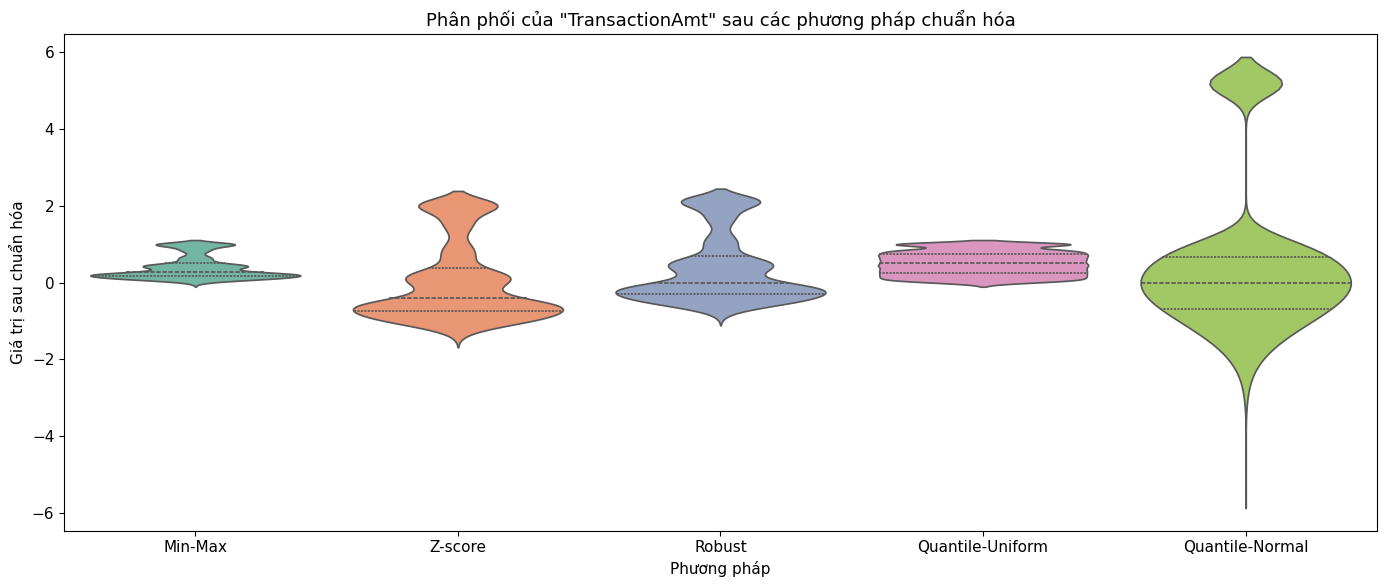

In [32]:
# Violin plot phân phối sau từng phương pháp chuẩn hóa (dùng cột đầu tiên)
ref_col_scale = scale_cols[0]
violin_data = []
for name, df_sc in scaled_dfs.items():
    tmp = pd.DataFrame({'value': df_sc[ref_col_scale], 'method': name})
    violin_data.append(tmp)
violin_df = pd.concat(violin_data, ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(x='method', y='value', data=violin_df, ax=ax,
               palette='Set2', inner='quartile')
ax.set_title(f'Phân phối của "{ref_col_scale}" sau các phương pháp chuẩn hóa', fontsize=13)
ax.set_xlabel('Phương pháp')
ax.set_ylabel('Giá trị sau chuẩn hóa')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_07_scaling_violin.png'), dpi=100, bbox_inches='tight')
plt.show()

In [33]:
# Áp dụng chuẩn hóa RobustScaler lên TOÀN BỘ cột số (không chỉ 10 cột benchmark)
print("\nÁp dụng RobustScaler lên tất cả cột số của train & test...")
all_num_for_scale = [c for c in all_num_cols_imp if c in train.columns and c in test.columns]
final_scaler = RobustScaler()
train[all_num_for_scale] = final_scaler.fit_transform(train[all_num_for_scale])
test[all_num_for_scale]  = final_scaler.transform(test[all_num_for_scale])
print(f"  Hoàn thành: {len(all_num_for_scale)} cột đã được chuẩn hóa bằng RobustScaler.")


Áp dụng RobustScaler lên tất cả cột số của train & test...
  Hoàn thành: 378 cột đã được chuẩn hóa bằng RobustScaler.


---
## 2.2.3d. Mã hóa biến phân loại nâng cao

Các mô hình ML yêu cầu đầu vào dạng số. Chiến lược mã hóa phụ thuộc vào **cardinality** (số giá trị duy nhất):

| Phương pháp | Cardinality | Cơ chế | Lưu ý |
|---|---|---|---|
| **One-Hot Encoding** | Thấp ($\leq 20$) | Mỗi giá trị thành một cột nhị phân | Tạo ma trận thưa; không có thứ tự |
| **Ordinal Encoding** | Bất kỳ | Map giá trị sang số nguyên $0, 1, \ldots, k-1$ | Giả định thứ tự; phù hợp cho tree models |
| **Target Encoding** | Cao | $\hat{x}_i = \mathbb{E}[y \mid x = x_i]$ | **Phải dùng CV** để tránh data leakage |
| **Binary Encoding** | Cao | Mã hóa ordinal rồi biểu diễn nhị phân | Số cột: $\lceil \log_2 k \rceil$ thay vì $k$ |
| **Frequency Encoding** | Bất kỳ | $\hat{x}_i = P(x = x_i)$ | Đơn giản, không phụ thuộc target |

**Target Encoding với Cross-Validation (5-fold)**: tránh leakage bằng cách encode fold $i$ chỉ dùng thông tin từ các fold còn lại.

**VIF (Variance Inflation Factor)** sau encoding để phát hiện đa cộng tuyến mới:

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

$R_j^2$ là $R^2$ khi hồi quy đặc trưng $j$ lên tất cả đặc trưng còn lại. $\text{VIF} > 10$ → đặc trưng bị giải thích gần như hoàn toàn bởi các đặc trưng khác → cân nhắc loại bỏ.

In [34]:
import category_encoders as ce
from sklearn.model_selection import KFold

# Xác định cột phân loại còn lại (object dtype)
# --- Quan trọng: chỉ lấy cột có trong CẢ train VÀ test để tránh KeyError ---
train_cat = set(train.select_dtypes(include=['object']).columns.tolist())
test_cat  = set(test.select_dtypes(include=['object']).columns.tolist())
# Cột chỉ có trong train (các identity cols bị thiếu trong test)
train_only_cat = train_cat - test_cat
if train_only_cat:
    print(f"Cột object CHỈ có trong train (bỏ qua khi encode test): {sorted(train_only_cat)}")
    # Add NaN placeholder columns to test so encoding won't crash
    for c in train_only_cat:
        test[c] = np.nan

cat_cols_remain = [c for c in train.select_dtypes(include=['object']).columns
                   if c in test.columns]
print(f"Số cột phân loại (chung cả train & test): {len(cat_cols_remain)}")
print("Cột phân loại:", cat_cols_remain[:10], "...")

# Số unique value của từng cột
cardinality = {col: train[col].nunique() for col in cat_cols_remain}
low_card  = [c for c, v in cardinality.items() if v <= 20]
high_card = [c for c, v in cardinality.items() if v > 20]
print(f"\nLow-cardinality (≤20 nghĩa): {len(low_card)} cột")
print(f"High-cardinality (>20 nghĩa): {len(high_card)} cột")

Cột object CHỈ có trong train (bỏ qua khi encode test): ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']
Số cột phân loại (chung cả train & test): 31
Cột phân loại: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5'] ...

Low-cardinality (≤20 nghĩa): 25 cột
High-cardinality (>20 nghĩa): 6 cột


In [35]:
# ── One-Hot Encoding (low-cardinality) ───────────────────────────────────────
target = train['isFraud']
enc_cols_demo = low_card[:3] + high_card[:2]  # demo cho một vài cột

print("\n=== Demo các phương pháp mã hóa ===")

# 1. One-Hot Encoding (lên TOÀN BỘ low-cardinality cols, merge vào DataFrame)
# Trước tiên đảm bảo low_card chỉ chứa các cột thực sự còn là object
low_card_exist = [c for c in low_card if c in train.columns and train[c].dtype == object]
if low_card_exist:
    ohe = ce.OneHotEncoder(cols=low_card_exist, use_cat_names=True, handle_missing='value')
    ohe_train = ohe.fit_transform(train[low_card_exist])
    ohe_test  = ohe.transform(test[low_card_exist])
    # Merge kết quả vào train/test, xóa cột gốc
    train = pd.concat([train.drop(columns=low_card_exist), ohe_train], axis=1)
    test  = pd.concat([test.drop(columns=low_card_exist),  ohe_test],  axis=1)
    print(f"One-Hot: {len(low_card_exist)} cột (card≤{20}) -> {ohe_train.shape[1]} cột binary | train: {train.shape}")
else:
    print("Không có cột low-cardinality nào để One-Hot encode.")

# Cập nhật lại danh sách cột phân loại còn lại sau OHE
# --- chỉ lấy cột còn trong test để tránh KeyError ở bước encode tiếp theo ---
cat_cols_remain = [c for c in train.select_dtypes(include=['object']).columns
                   if c in test.columns]

# 2. Ordinal Encoding (toàn bộ cat cols chung)
from sklearn.preprocessing import LabelEncoder
ordinal_encoders = {}
# cat_cols_remain đã được giới hạn chỉ cột có trong cả train & test
for col in cat_cols_remain:
    if col not in train.columns or col not in test.columns:
        continue
    le = LabelEncoder()
    combined = list(train[col].astype(str)) + list(test[col].astype(str))
    le.fit(combined)
    train[f'{col}_ord'] = le.transform(train[col].astype(str))
    test[f'{col}_ord']  = le.transform(test[col].astype(str))
    ordinal_encoders[col] = le
print(f"Ordinal Encoding: thêm {len(cat_cols_remain)} cột _ord")

# 3. Target Encoding (với cross-validation 5-fold để tránh leakage)
def target_encode_cv(df_train, col, target_col, n_splits=5, seed=42):
    """Target encoding với cross-validation để tránh data leakage."""
    out = np.zeros(len(df_train))
    global_mean = df_train[target_col].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    
    for tr_idx, val_idx in kf.split(df_train):
        tr_data = df_train.iloc[tr_idx]
        means = tr_data.groupby(col)[target_col].mean()
        val_cats = df_train.iloc[val_idx][col]
        out[val_idx] = val_cats.map(means).fillna(global_mean).values
    return out

target_means_store = {}
# Encode TOÀN BỘ cột phân loại còn lại với Target Encoding (không chỉ 5 cột demo)
print(f"\nTarget Encoding (5-fold CV) – {len(cat_cols_remain)} cột...")
for col in cat_cols_remain:
    if col not in train.columns:
        continue
    train[f'{col}_te'] = target_encode_cv(train, col, 'isFraud')
    global_mean = train['isFraud'].mean()
    means_map = train.groupby(col)['isFraud'].mean()
    target_means_store[col] = means_map
    test[f'{col}_te'] = test[col].map(means_map).fillna(global_mean)
print(f"  Đã thêm {len(cat_cols_remain)} cột _te")

# 4. Binary Encoding (high-cardinality > 20 giá trị) – merge vào train/test
print("\nBinary Encoding (high-cardinality cols)...")
# Cập nhật high_card theo object cols còn lại
high_card_remain = [c for c in cat_cols_remain if c in train.columns and train[c].dtype == object]
if high_card_remain:
    binary_enc = ce.BinaryEncoder(cols=high_card_remain, handle_missing='value')
    be_train = binary_enc.fit_transform(train[high_card_remain])
    be_test  = binary_enc.transform(test[high_card_remain])
    # Merge vào train/test, xóa cột gốc
    train = pd.concat([train.drop(columns=high_card_remain), be_train], axis=1)
    test  = pd.concat([test.drop(columns=high_card_remain),  be_test],  axis=1)
    print(f"  Binary Encoding: {len(high_card_remain)} cột -> {be_train.shape[1]} cột nhị phân | train: {train.shape}")
else:
    print("  Không có cột high-cardinality nào còn lại sau OHE.")

# 5. Frequency Encoding – TOÀN BỘ cột phân loại còn lại
print("\nFrequency Encoding...")
freq_cols_all = [c for c in cat_cols_remain if c in train.columns and train[c].dtype == object]
for col in freq_cols_all:
    freq_map = train[col].value_counts(normalize=True)
    train[f'{col}_freq'] = train[col].map(freq_map).fillna(0)
    test[f'{col}_freq']  = test[col].map(freq_map).fillna(0)
print(f"  Đã thêm {len(freq_cols_all)} cột _freq")

# Xóa cột object gốc còn sót lại sau tất cả bước encoding
residual_obj = train.select_dtypes(include=['object']).columns.tolist()
residual_obj_safe = [c for c in residual_obj if c != 'isFraud']
if residual_obj_safe:
    train = train.drop(columns=residual_obj_safe)
    test  = test.drop(columns=[c for c in residual_obj_safe if c in test.columns])
    print(f"\nĐã xóa {len(residual_obj_safe)} cột object gốc còn sót: {residual_obj_safe[:5]}...")
print(f"-> train shape sau encoding: {train.shape}")


=== Demo các phương pháp mã hóa ===
One-Hot: 25 cột (card≤20) -> 62 cột binary | train: (590540, 471)
Ordinal Encoding: thêm 6 cột _ord

Target Encoding (5-fold CV) – 6 cột...


KeyboardInterrupt: 

In [ ]:
# Variance Inflation Factor (VIF) để phát hiện đa cộng tuyến mới
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = [c for c in train.select_dtypes(include=[np.number]).columns
            if c not in ('isFraud', 'TransactionID') and train[c].std() > 0][:15]

vif_sample = train[vif_cols].dropna().sample(min(3000, len(train)), random_state=SEED)
vif_data = pd.DataFrame({'feature': vif_cols,
                          'VIF': [variance_inflation_factor(vif_sample.values, i)
                                  for i in range(len(vif_cols))]})
vif_data = vif_data.sort_values('VIF', ascending=False)
print("\n=== VIF – Top 15 đặc trưng (sau encoding) ===")
print(vif_data.to_string(index=False))
high_vif = vif_data[vif_data['VIF'] > 10]
print(f"\n-> Số đặc trưng có VIF > 10 (đa cộng tuyến đáng ngại): {len(high_vif)}")
if len(high_vif) > 0:
    print("  Cần xem xét loại bỏ hoặc kết hợp:", high_vif['feature'].tolist())

---
## 2.2.3e. Lựa chọn và giảm chiều đặc trưng

### a) Phương pháp lọc thống kê (Filter Methods)

Đánh giá độc lập từng đặc trưng, không phụ thuộc mô hình:

| Phương pháp | Thống kê | Phù hợp với |
|---|---|---|
| **ANOVA F-test** | $F = \frac{MS_{\text{between}}}{MS_{\text{within}}}$ | Đặc trưng số, quan hệ tuyến tính với target |
| **Mutual Information** | $I(X;Y) = \sum_{x,y} p(x,y)\log\frac{p(x,y)}{p(x)p(y)}$ | Đặc trưng số, quan hệ phi tuyến |
| **Chi-square test** | $\chi^2 = \sum\frac{(O-E)^2}{E}$ | Đặc trưng phân loại (giá trị $\geq 0$) |

### b) Phương pháp dựa trên mô hình (Embedded Methods)

- **Random Forest / Gradient Boosting importance**: mức giảm trung bình Gini impurity khi đặc trưng được dùng để phân tách
- **RFE (Recursive Feature Elimination)**: huấn luyện mô hình, loại đặc trưng kém quan trọng nhất, lặp lại → chậm nhưng chính xác

### c) Giảm chiều (Dimensionality Reduction)

- **PCA**: tìm $k$ thành phần chính $\mathbf{z}_i = \mathbf{W}^T \mathbf{x}_i$ giữ $\geq 95\%$ phương sai giải thích tích lũy
- **t-SNE**: bảo toàn cấu trúc cục bộ bằng cách tối thiểu KL divergence giữa phân phối trong không gian gốc và 2D – chỉ dùng để **trực quan hóa**, không dùng làm feature cho mô hình

### Phân tích V columns (339 cột ẩn danh)

#### Cell 5 – Correlation matrix trong từng nhóm V (chọn đại diện)

In [ ]:
# 11 nhóm V theo phạm vi cột
v_group_ranges = [(1,11),(12,34),(35,52),(53,74),(75,94),(95,137),(138,166),(167,216),(217,278),(279,321),(322,339)]

# Đếm số cặp tương quan cao (|r| > 0.9) trong mỗi nhóm
high_corr_counts = {}
rep_cols = []  # đại diện mỗi nhóm: cột ít thiếu nhất

for i, (lo, hi) in enumerate(v_group_ranges):
    grp_cols = [f'V{j}' for j in range(lo, hi+1) if f'V{j}' in train.columns]
    if len(grp_cols) < 2:
        continue
    sample = train[grp_cols].sample(min(5000, len(train)), random_state=SEED)
    corr   = sample.corr().abs()
    n_high = int(((corr > 0.9) & (corr < 1)).sum().sum() / 2)
    high_corr_counts[f'G{i+1} V{lo}-V{hi}'] = n_high
    # Đại diện = cột ít NaN nhất trong nhóm
    rep = train[grp_cols].isnull().mean().idxmin()
    rep_cols.append(rep)

print("Số cặp |r| > 0.9 trong mỗi nhóm V:")
for k, v in high_corr_counts.items():
    print(f"  {k}: {v} cặp")

print(f"\nCột đại diện đề xuất cho mỗi nhóm ({len(rep_cols)} cột):")
print(rep_cols)

#### Cell 13 – Xác nhận 11 nhóm bằng missing pattern

In [ ]:
# Tính missing rate từng cột V, nhóm theo ranh giới
v_group_names = [f'G{i+1} (V{lo}-V{hi})' for i, (lo, hi) in enumerate(v_group_ranges)]
v_group_miss  = {}
for name, (lo, hi) in zip(v_group_names, v_group_ranges):
    cols = [f'V{j}' for j in range(lo, hi+1) if f'V{j}' in train.columns]
    if cols:
        v_group_miss[name] = train[cols].isnull().mean().mean() * 100

v_miss_df = pd.Series(v_group_miss)

fig, ax = plt.subplots(figsize=(14, 5))
v_miss_df.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('Tỉ lệ thiếu trung bình theo 11 nhóm V')
ax.set_ylabel('% thiếu trung bình')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(v_miss_df.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_11_v_groups.png'), dpi=100, bbox_inches='tight')
plt.show()

#### Cell 14 – Trong mỗi nhóm: correlation -> giữ cột corr < 0.9 với nhau

In [ ]:
v_keep_cols = []

for i, (lo, hi) in enumerate(v_group_ranges):
    grp_cols = [f'V{j}' for j in range(lo, hi+1) if f'V{j}' in train.columns]
    if len(grp_cols) < 2:
        v_keep_cols.extend(grp_cols)
        continue
    sample = train[grp_cols].sample(min(5000, len(train)), random_state=SEED)
    corr   = sample.corr().abs()
    # Greedy: giữ cột, loại cột nào corr > 0.9 với cột đã giữ
    keep = []
    for col in grp_cols:
        if not keep:
            keep.append(col)
        elif all(corr.loc[col, k] < 0.9 for k in keep):
            keep.append(col)
    v_keep_cols.extend(keep)

print(f"Tổng cột V gốc   : {len([c for c in train.columns if c.startswith('V')])}")
print(f"Sau lọc corr > 0.9: {len(v_keep_cols)} cột giữ lại")
print(f"Loại bỏ           : {len([c for c in train.columns if c.startswith('V')]) - len(v_keep_cols)} cột")

#### Cell 15 – RF importance trên V columns -> top 20

In [ ]:
from sklearn.ensemble import RandomForestClassifier  # noqa: F811 (re-imported early for V-group RF analysis)

v_sample_cols = v_keep_cols[:50]  # giới hạn 50 cột để chạy nhanh
X_v = train[v_sample_cols].fillna(-999).sample(min(20000, len(train)), random_state=SEED)
y_v = train['isFraud'].loc[X_v.index]

rf_v = RandomForestClassifier(n_estimators=100, max_depth=6, n_jobs=-1, random_state=SEED)
rf_v.fit(X_v, y_v)

v_importance = pd.DataFrame({'feature': v_sample_cols,
                              'importance': rf_v.feature_importances_})
v_importance = v_importance.sort_values('importance', ascending=False)

print("Top 20 V features theo RF importance:")
print(v_importance.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
v_importance.head(20).plot(x='feature', y='importance', kind='barh',
                            ax=ax, color='forestgreen', legend=False)
ax.set_title('Top 20 V columns – RF Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_12_v_importance.png'), dpi=100, bbox_inches='tight')
plt.show()

#### Cell 16 – PCA trên từng nhóm V -> số thành phần cần thiết

In [ ]:
from sklearn.decomposition import PCA  # noqa: F811 (re-imported early for V-group PCA analysis)

pca_results = {}
for i, (lo, hi) in enumerate(v_group_ranges[:6]):  # chỉ 6 nhóm đầu để tiết kiệm thời gian
    grp_cols = [c for c in v_keep_cols if c in [f'V{j}' for j in range(lo, hi+1)]]
    if len(grp_cols) < 3:
        continue
    X_grp = train[grp_cols].fillna(0).sample(min(10000, len(train)), random_state=SEED)
    X_sc  = StandardScaler().fit_transform(X_grp)
    pca_g = PCA(n_components=min(len(grp_cols), 10), random_state=SEED)
    pca_g.fit(X_sc)
    cumvar = pca_g.explained_variance_ratio_.cumsum()
    n95    = int((cumvar >= 0.95).argmax()) + 1
    pca_results[f'G{i+1} (V{lo}-V{hi})'] = {
        'n_cols': len(grp_cols), 'n_pca_95pct': n95
    }

pca_df = pd.DataFrame(pca_results).T
print("PCA per V-group (95% variance):")
print(pca_df.to_string())

#### Cell 17 – Kết luận: danh sách V features nên giữ

In [ ]:
top_v_by_rf  = v_importance.head(20)['feature'].tolist()
top_v_by_mi  = []
if v_keep_cols:
    X_v_mi = train[v_keep_cols[:50]].fillna(-999).sample(min(10000, len(train)), random_state=SEED)
    y_v_mi = train['isFraud'].loc[X_v_mi.index]
    mi_v   = mutual_info_classif(X_v_mi, y_v_mi, random_state=SEED)
    mi_v_df = pd.DataFrame({'feature': v_keep_cols[:50], 'MI': mi_v})
    top_v_by_mi = mi_v_df.sort_values('MI', ascending=False).head(20)['feature'].tolist()

# Union của RF và MI top 20
final_v_cols = list(set(top_v_by_rf) | set(top_v_by_mi))

print(f"V columns gốc          : {len([c for c in train.columns if c.startswith('V')])}")
print(f"Sau lọc corr > 0.9     : {len(v_keep_cols)}")
print(f"Top 20 RF importance   : {len(top_v_by_rf)}")
print(f"Top 20 Mutual Info     : {len(top_v_by_mi)}")
print(f"Danh sách cuối (union) : {len(final_v_cols)} cột")
print("\nCác V features được giữ lại:")
print(sorted(final_v_cols, key=lambda x: int(x[1:])))

In [ ]:
from sklearn.feature_selection import (f_classif, chi2, mutual_info_classif,
                                        SelectKBest, RFE)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Chuẩn bị X, y cho feature selection
# Lấy các cột số + cột _ord đã mã hóa
fs_num_cols = [c for c in train.select_dtypes(include=[np.number]).columns
               if c not in ('isFraud', 'TransactionID', 'TransactionDT')]
X_fs = train[fs_num_cols].fillna(0)
y_fs = train['isFraud']

# Lấy tập con để tránh OOM
FS_N = min(30_000, len(X_fs))
X_fs_sample = X_fs.sample(FS_N, random_state=SEED)
y_fs_sample = y_fs.loc[X_fs_sample.index]

print(f"Feature selection trên {X_fs_sample.shape[0]} dòng × {X_fs_sample.shape[1]} cột")

In [ ]:
# ── a) Lọc thống kê ────────────────────────────────────────────────────────
print("\n=== a) Lọc thống kê ===")

# ANOVA F-test (thuộc tính số)
f_vals, p_anova = f_classif(X_fs_sample, y_fs_sample)
anova_df = pd.DataFrame({'feature': fs_num_cols, 'F_stat': f_vals, 'p_value': p_anova})
anova_df = anova_df.sort_values('F_stat', ascending=False)
print("\nANOVA F-test – Top 15 thuộc tính:")
print(anova_df.head(15).to_string(index=False))
top_anova_feats = anova_df.head(20)['feature'].tolist()

# Mutual Information
mi_scores = mutual_info_classif(X_fs_sample, y_fs_sample, random_state=SEED)
mi_df = pd.DataFrame({'feature': fs_num_cols, 'MI_score': mi_scores})
mi_df = mi_df.sort_values('MI_score', ascending=False)
print("\nMutual Information – Top 15 thuộc tính:")
print(mi_df.head(15).to_string(index=False))
top_mi_feats = mi_df.head(20)['feature'].tolist()

### Chi-square test cho thuộc tính phân loại (đã encode)
Theo yêu cầu 2.2.3e: *"Chi-square test (thuộc tính phân loại)"*
Dùng các cột có giá trị không âm (ordinal-encoded, binary, freq encoding)

In [ ]:
print("\n=== Chi-square test (thuộc tính phân loại đã encode) ===")
# Lấy cột _ord (ordinal-encoded) vì chi2 yêu cầu giá trị ≥ 0
ordinal_cols_for_chi2 = [c for c in fs_num_cols if c.endswith('_ord')]
if not ordinal_cols_for_chi2:
    # fallback: dùng cột binả (min ≥ 0) nếu không có _ord
    ordinal_cols_for_chi2 = [c for c in fs_num_cols
                              if X_fs_sample[c].min() >= 0][:20]

if ordinal_cols_for_chi2:
    X_chi2 = X_fs_sample[ordinal_cols_for_chi2].fillna(0)
    # Đảm bảo không có giá trị âm (chuẩn hóa shift nếu cần)
    X_chi2 = X_chi2 - X_chi2.min()
    chi2_scores, chi2_pvals = chi2(X_chi2, y_fs_sample)
    chi2_df = pd.DataFrame({
        'feature' : ordinal_cols_for_chi2,
        'chi2_stat': chi2_scores,
        'p_value'  : chi2_pvals
    }).sort_values('chi2_stat', ascending=False)
    print(f"Chi-square test trên {len(ordinal_cols_for_chi2)} cột phân loại (encoded):")
    print(chi2_df.head(15).to_string(index=False))
    top_chi2_feats = chi2_df[chi2_df['p_value'] < 0.05]['feature'].tolist()
    print(f"\n-> {len(top_chi2_feats)} cột có p < 0.05 (phân biệt kỳ thuật giữa các lớp)")

    # Biểu đồ Chi-square score
    fig, ax = plt.subplots(figsize=(12, 5))
    chi2_df.head(15).plot(x='feature', y='chi2_stat', kind='barh',
                           ax=ax, color='mediumorchid', legend=False)
    ax.set_title('Chi-square test – Top 15 thuộc tính phân loại', fontsize=12)
    ax.set_xlabel('Chi2 Statistic')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig_08b_chi2_test.png'), dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("Không tìm thấy cột phân loại đã encode – bỏ qua chi-square test.")

In [ ]:
# Biểu đồ so sánh F-test vs MI
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
anova_df.head(20).plot(x='feature', y='F_stat', kind='barh', ax=axes[0],
                       color='steelblue', legend=False)
axes[0].set_title('ANOVA F-test (Top 20)', fontsize=12)
axes[0].set_xlabel('F-statistic')

mi_df.head(20).plot(x='feature', y='MI_score', kind='barh', ax=axes[1],
                    color='darkorange', legend=False)
axes[1].set_title('Mutual Information (Top 20)', fontsize=12)
axes[1].set_xlabel('MI Score')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_08_statistical_filters.png'), dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# ── b) Lọc dựa trên mô hình ────────────────────────────────────────────────
print("\n=== b) Feature Importance từ Random Forest & Gradient Boosting ===")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=6, n_jobs=-1, random_state=SEED)
rf.fit(X_fs_sample, y_fs_sample)
rf_importance = pd.DataFrame({'feature': fs_num_cols, 'RF_importance': rf.feature_importances_})
rf_importance = rf_importance.sort_values('RF_importance', ascending=False)
print("RF – Top 15:")
print(rf_importance.head(15).to_string(index=False))
top_rf_feats = rf_importance.head(20)['feature'].tolist()

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=SEED)
gb.fit(X_fs_sample, y_fs_sample)
gb_importance = pd.DataFrame({'feature': fs_num_cols, 'GB_importance': gb.feature_importances_})
gb_importance = gb_importance.sort_values('GB_importance', ascending=False)
print("\nGB – Top 15:")
print(gb_importance.head(15).to_string(index=False))
top_gb_feats = gb_importance.head(20)['feature'].tolist()

In [ ]:
# Biểu đồ RF vs GB importance
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
rf_importance.head(20).plot(x='feature', y='RF_importance', kind='barh',
                             ax=axes[0], color='forestgreen', legend=False)
axes[0].set_title('Random Forest Feature Importance (Top 20)', fontsize=12)

gb_importance.head(20).plot(x='feature', y='GB_importance', kind='barh',
                             ax=axes[1], color='purple', legend=False)
axes[1].set_title('Gradient Boosting Feature Importance (Top 20)', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_09_model_importance.png'), dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# RFE với Logistic Regression (cross-validation)
# TODO: Bỏ comment để chạy – RFE chạy chậm (fit LR nhiều lần), có thể mất vài phút
# Lưu ý hiệu năng: RFE phải fit LR nhiều lần -> dùng subsample nhỏ + saga solver
# print("\n=== RFE với LogisticRegression (3-fold CV, subsample=3000) ===")
# N_FEATS = [5, 10]
# rfe_scores = {}
#
# # Dùng subsample 3000 rows: đủ để đánh giá, chạy trong ~30s thay vì >10 phút
# RFE_N = min(3000, len(X_fs_sample))
# X_rfe = X_fs_sample.sample(RFE_N, random_state=SEED)
# y_rfe = y_fs_sample.loc[X_rfe.index]
#
# # saga solver hội tụ nhanh hơn lbfgs với dữ liệu lớn/nhiều feature
# cv_rfe = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
#
# for n in N_FEATS:
#     rfe = RFE(estimator=LogisticRegression(max_iter=100, solver='saga',
#                                            random_state=SEED, C=0.1),
#               n_features_to_select=n)
#     pipe = Pipeline([('rfe', rfe),
#                      ('clf', LogisticRegression(max_iter=100, solver='saga',
#                                                 random_state=SEED, C=0.1))])
#     scores = cross_val_score(pipe, X_rfe, y_rfe, cv=cv_rfe,
#                              scoring='f1', n_jobs=-1)
#     rfe_scores[n] = round(scores.mean(), 4)
#     print(f"  n_features={n:3d}: F1={scores.mean():.4f} +/- {scores.std():.4f}")
#
# # Cross-val F1 score theo số lượng đặc trưng (dùng cùng subsample và cv như RFE)
# all_n_feats = [5, 10, 15, 20, 25]
# cv_f1_scores = {}
#
# for n in all_n_feats:
#     top_n_feats = rf_importance.head(n)['feature'].tolist()
#     scores = cross_val_score(LogisticRegression(max_iter=100, solver='saga',
#                                                  random_state=SEED, C=0.1),
#                              X_rfe[top_n_feats], y_rfe,
#                              cv=cv_rfe, scoring='f1', n_jobs=-1)
#     cv_f1_scores[n] = scores.mean()
#
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(list(cv_f1_scores.keys()), list(cv_f1_scores.values()),
#         marker='o', color='steelblue', linewidth=2)
# ax.set_xlabel('So luong dac trung (tu RF importance)')
# ax.set_ylabel('5-Fold CV F1-score')
# ax.set_title('Hieu nang mo hinh vs So luong dac trung')
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig_10_feature_count_vs_f1.png'), dpi=100, bbox_inches='tight')
# plt.show()

In [ ]:
# ── c) Giảm chiều ──────────────────────────────────────────────────────────
print("\n=== c) Giảm chiều: PCA & t-SNE ===")

# PCA
pca = PCA(n_components=0.95, random_state=SEED)  # giữ 95% variance
X_pca = pca.fit_transform(X_fs_sample.fillna(0))
print(f"PCA: {X_fs_sample.shape[1]} -> {X_pca.shape[1]} thành phần (95% variance)")

# Biểu đồ cumulative explained variance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[0].plot(range(1, len(cumvar)+1), cumvar, marker='.', color='steelblue')
axes[0].axhline(0.95, color='red', linestyle='--', label='95% variance')
axes[0].set_xlabel('Số thành phần PCA')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA – Phương sai giải thích tích lũy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# t-SNE trực quan hóa 2D (tập nhỏ)
TSNE_N = min(3000, len(X_fs_sample))
X_tsne_in = X_fs_sample.sample(TSNE_N, random_state=SEED)
y_tsne = y_fs_sample.loc[X_tsne_in.index]
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=500)
X_tsne = tsne.fit_transform(X_tsne_in.fillna(0))

axes[1].scatter(X_tsne[y_tsne == 0, 0], X_tsne[y_tsne == 0, 1],
                c='steelblue', alpha=0.4, s=5, label='Normal (0)')
axes[1].scatter(X_tsne[y_tsne == 1, 0], X_tsne[y_tsne == 1, 1],
                c='tomato', alpha=0.8, s=10, label='Fraud (1)')
axes[1].set_title(f't-SNE (n={TSNE_N}): Phân tách lớp Fraud vs Normal')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_11_pca_tsne.png'), dpi=100, bbox_inches='tight')
plt.show()

# UMAP (nếu cài đặt được)
try:
    import umap
    print("\nUMAP đang chạy...")
    reducer = umap.UMAP(n_components=2, random_state=SEED)
    X_umap = reducer.fit_transform(X_tsne_in.fillna(0))
    
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(X_umap[y_tsne == 0, 0], X_umap[y_tsne == 0, 1],
               c='steelblue', alpha=0.4, s=5, label='Normal (0)')
    ax.scatter(X_umap[y_tsne == 1, 0], X_umap[y_tsne == 1, 1],
               c='tomato', alpha=0.8, s=15, label='Fraud (1)')
    ax.set_title(f'UMAP (n={TSNE_N}): Phân tách lớp Fraud vs Normal')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig_12_umap.png'), dpi=100, bbox_inches='tight')
    plt.show()
    print("-> UMAP hoàn thành.")
except ImportError:
    print("-> UMAP không được cài đặt. Bỏ qua (pip install umap-learn).")

---
## 2.2.3f. [Nâng cao] Phát hiện và xử lý mất cân bằng lớp

Dữ liệu gian lận thường có tỉ lệ lớp thiểu số ($y=1$) rất thấp (~3%). Nếu không xử lý,
mô hình sẽ thiên về lớp đa số và có accuracy cao nhưng recall thấp trên lớp Fraud.

| Chiến lược | Cơ chế | Ưu điểm | Nhược điểm |
|---|---|---|---|
| **SMOTE** | Tạo mẫu tổng hợp theo nội suy giữa điểm thiểu số và $k$-nearest neighbors | Không mất data; tăng diversity | Có thể tạo nhiễu ở vùng biên phức tạp |
| **ADASYN** | SMOTE thích nghi – tạo nhiều mẫu hơn ở vùng khó phân loại (gần biên) | Tập trung hard cases | Nhạy cảm với noise |
| **Random Undersampling** | Xóa ngẫu nhiên mẫu lớp đa số | Nhanh, giảm chi phí tính toán | Mất thông tin từ lớp đa số |

**Đánh giá**: dùng **F1-macro** (trung bình không trọng số giữa các lớp) và **AUC-ROC** thay vì accuracy.

In [ ]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, classification_report)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

#### Cell 2 – Tỉ lệ Fraud (class balance)

In [ ]:
fraud_counts = train['isFraud'].value_counts()
fraud_pct    = train['isFraud'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Normal (0)', 'Fraud (1)'], fraud_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Số lượng theo lớp')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(fraud_pct.values, labels=[f'Normal\n{fraud_pct[0]:.1f}%', f'Fraud\n{fraud_pct[1]:.1f}%'],
            colors=['steelblue', 'tomato'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Tỉ lệ lớp')

plt.suptitle('Class Balance – isFraud', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_01_class_balance.png'), dpi=100, bbox_inches='tight')
plt.show()
print(fraud_counts.to_string())

print("=== Phân tích mất cân bằng lớp ===")
class_counts = y_fs.value_counts()
imbalance_ratio = class_counts[0] / class_counts[1]
print(f"  Lớp 0 (Normal): {class_counts[0]:,} ({class_counts[0]/len(y_fs):.2%})")
print(f"  Lớp 1 (Fraud) : {class_counts[1]:,} ({class_counts[1]/len(y_fs):.2%})")
print(f"  Tỉ lệ mất cân bằng (0:1) = {imbalance_ratio:.1f}:1")

> **Tại sao KHÔNG resampling trước khi chia train/test?**
>
> 1. Resampling tạo ra dữ liệu tổng hợp (SMOTE) hoặc xóa bớt có chọn lọc.
> 2. Nếu resampling **trước** khi chia, tập test sẽ bị "nhiễm" (contaminated) bởi dữ liệu tổng hợp
>    hoặc phân phối bị bóp méo – không còn phản ánh phân phối thực tế của bài toán.
>    Kết quả: metrics đo được không còn đáng tin.
> 3. **Đúng quy trình**: Chia train/test **trước** → Chỉ resampling trên tập **train**.
> 4. Tập test luôn phải giữ nguyên phân phối gốc để đánh giá khách quan.

In [ ]:
# Chuẩn bị dữ liệu cho phần imbalance handling
top_feats_imb = rf_importance.head(25)['feature'].tolist()
X_imb = X_fs[top_feats_imb].fillna(0)
y_imb = y_fs

# Chia train/test TRƯỚC (stratified)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=SEED, stratify=y_imb
)
print(f"\nTập train: {X_tr.shape[0]:,} dòng | Tập test: {X_te.shape[0]:,} dòng")
print(f"  Train lớp 1 ratio: {y_tr.mean():.3f}")
print(f"  Test  lớp 1 ratio: {y_te.mean():.3f}")

In [ ]:
# Định nghĩa và áp dụng các chiến lược resampling (CHỈ trên train)
resampling_strategies = {
    'No Resampling'       : None,
    'SMOTE'               : SMOTE(random_state=SEED, k_neighbors=5),
    'ADASYN'              : ADASYN(random_state=SEED),
    'Random Undersampling': RandomUnderSampler(random_state=SEED),
}

imbalance_results = []
clf_imb = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=SEED)

for strategy_name, resampler in resampling_strategies.items():
    print(f"\n--- {strategy_name} ---")
    
    if resampler is not None:
        X_res, y_res = resampler.fit_resample(X_tr, y_tr)
        print(f"  Sau resampling: {X_res.shape[0]:,} dòng | lớp 1 ratio: {y_res.mean():.3f}")
    else:
        X_res, y_res = X_tr.copy(), y_tr.copy()
    
    clf_imb.fit(X_res, y_res)
    y_pred = clf_imb.predict(X_te)
    y_prob = clf_imb.predict_proba(X_te)[:, 1]
    
    prec   = precision_score(y_te, y_pred, zero_division=0)
    rec    = recall_score(y_te, y_pred, zero_division=0)
    f1_mac = f1_score(y_te, y_pred, average='macro', zero_division=0)
    auc    = roc_auc_score(y_te, y_prob)
    
    print(f"  Precision={prec:.4f} | Recall={rec:.4f} | F1-macro={f1_mac:.4f} | AUC-ROC={auc:.4f}")
    
    imbalance_results.append({
        'Chiến lược'   : strategy_name,
        'Precision'    : round(prec, 4),
        'Recall'       : round(rec, 4),
        'F1-macro'     : round(f1_mac, 4),
        'AUC-ROC'      : round(auc, 4),
    })

In [ ]:
imbalance_df = pd.DataFrame(imbalance_results)
print("\n=== Bảng tổng kết: So sánh chiến lược xử lý mất cân bằng lớp ===")
print(imbalance_df.to_string(index=False))

# Biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metrics_to_plot = ['F1-macro', 'AUC-ROC', 'Precision', 'Recall']
x = range(len(imbalance_df))

for ax, metric in zip(axes, ['F1-macro', 'AUC-ROC']):
    ax.bar([r['Chiến lược'] for r in imbalance_results],
           [r[metric] for r in imbalance_results],
           color=['steelblue', 'forestgreen', 'darkorange', 'tomato'],
           edgecolor='white')
    ax.set_title(f'So sánh {metric}', fontsize=12)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('So sánh chiến lược xử lý mất cân bằng lớp\n(đánh giá trên tập test GỐC)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_13_imbalance_strategies.png'), dpi=100, bbox_inches='tight')
plt.show()

---
## Tóm tắt Pipeline Tiền Xử Lý Hoàn Chỉnh

| Bước | Nội dung | Kết quả / Lựa chọn |
|---|---|---|
| **1. Load & Merge** | `train_transaction` + `train_identity` (left join theo `TransactionID`) | Dataset hợp nhất |
| **2. Memory** | `reduce_mem_usage` – downcast dtype về int8/float32 | Giảm RAM đáng kể |
| **3. EDA** | D'Agostino-Pearson, Pearson/Spearman heatmap, missingno + Little's MCAR | Xác định cơ chế thiếu (MAR) |
| **4. Imputation** | So sánh 7 chiến lược: Mean, Median, Mode, kNN-3/5/10, MICE | Chọn RMSE thấp nhất; áp dụng Median cho production |
| **5. Outlier** | IQR, Z-score, Isolation Forest, LOF, DBSCAN; đánh giá qua KS test | IQR clipping – bảo toàn phân phối |
| **6. Scaling** | Min-Max, Z-score, Robust, Quantile; kiểm định Levene | RobustScaler – bền vững với outlier còn sót |
| **7. Encoding** | OHE (low-card) + Ordinal + Target CV + Binary + Frequency; VIF | Phát hiện đa cộng tuyến mới |
| **8. Feature Selection** | ANOVA F-test, Mutual Information, Chi-square, RF/GB importance | Xác định đặc trưng quan trọng |
| **9. Dim Reduction** | PCA (95% variance), t-SNE, UMAP (tùy chọn) | Trực quan hóa cấu trúc dữ liệu |
| **10. Imbalance** | SMOTE, ADASYN, Random Undersampling – chỉ trên tập train | Báo cáo F1-macro, AUC-ROC trên tập test gốc |